# Mega Table Joining

This should be taking my Gaia DR2 tables for the MORDOR survey (which only contain Gaia DR2 data and some notes I've added), and it should be making a Gaia DR3 table, PanSTARRS photometry table (mags with mag uncertainties), 2MASS (mags with uncertainties).

https://nbviewer.org/github/AllenDowney/AstronomicalData/blob/main/05_join.ipynb

In later attempts I'll probably try to add additional catalogues. But for now, we should try to keep it to a minimal amount of stuff.

In [145]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coord
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column, vstack, join
#import scipy.interpolate as scinterp
import time
import pyvo
from astroquery.vizier import Vizier

from astroquery.gaia import Gaia


sys.path.append('../')


In [2]:
Gaia.login(credentials_file='../Gaia_credentials.txt')

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK


So now we've imported what are hopefully all of the libraries we'll need to import our Gaia DR2 table

input_file='20190516B_retargeted_purple_search_gaia_scbd_20230301_update_DCs_1677713100.csv'
input_directory='/Users/BenKaiser/Desktop/MORDOR_Survey_forPaper/Goodman_spectra/DCs/'

In [3]:
input_file='full_MORDOR_survey_1681141339.csv'
input_directory='/Users/BenKaiser/Desktop/MORDOR_Survey_forPaper/Goodman_spectra/'

I need to automate the naming of these table files because I'm going to have several of them going through here at this rate...

In [4]:
name_base=input_file.split('.')[0].lower()
name_base_parts=name_base.split('_')[-4:]
print(name_base_parts)
name_base='_'.join(name_base_parts)
name_base='mordor_'+name_base
print(name_base)

['full', 'mordor', 'survey', '1681141339']
mordor_full_mordor_survey_1681141339


In [5]:
input_table=Table.read(input_directory+input_file,format='ascii.csv')

In [6]:
length=len(input_table)
input_table.add_column(np.zeros(length),name='source_id')

In [7]:
input_table.pprint()

       name                 designation           ...    g_abs    source_id
----------------- ------------------------------- ... ----------- ---------
MORDOR J0008-2404 b'Gaia DR2 2336521827465439616' ... 15.83131084       0.0
  SDSS J0049+2244 b'Gaia DR2 2802321579156605568' ... 15.07368014       0.0
MORDOR J0110-5926 b'Gaia DR2 4909222871450620416' ... 15.45486534       0.0
MORDOR J0110-5600 b'Gaia DR2 4913565903725184640' ... 14.64666791       0.0
MORDOR J0126-4707 b'Gaia DR2 4930805868092016256' ... 14.39357931       0.0
  SDSS J0132+1823 b'Gaia DR2 2593774421282488832' ... 14.64289736       0.0
MORDOR J0135-6306 b'Gaia DR2 4712157368044092928' ... 14.54516856       0.0
       LEHPM 1774 b'Gaia DR2 5140433498003756160' ... 15.68093688       0.0
  LSPM J0211+0835 b'Gaia DR2 2521858084423378176' ... 14.54609154       0.0
MORDOR J0225-3312 b'Gaia DR2 4967454759604815360' ... 15.14265539       0.0
              ...                             ... ...         ...       ...
MORDOR J2126

Ok, and our source_id column is screwed up because it used to have more precision than it currently does, so I'm changing the dtype to allow for more precision hopefully

In [8]:
input_table['source_id']=Column(input_table['source_id'],dtype=np.int64,name='source_id')

In [9]:
test_source_id=np.copy(input_table[0]['source_id'])

In [10]:
print(test_source_id)

0


In [11]:
for row in input_table:
    row['source_id']=row['designation'].replace("'","").split(' ')[-1]

In [12]:
print(input_table[0]['source_id'],test_source_id)

2336521827465439616 0


In [13]:
print(input_table[0]['source_id'],test_source_id,input_table[0]['designation'])

2336521827465439616 0 b'Gaia DR2 2336521827465439616'


Ok. That worked, so now we have a source_id column that has an integer in it as it used to, and has regained its numerical precision to actually specify the full ID.

## Uploading the Gaia DR2 Table to my workspace... I would think this should only happen like one time ever...

In [14]:
upload_table=Table(input_table['source_id','ra','dec'])

In [15]:
upload_table.pprint()

     source_id           ra         dec     
------------------- ----------- ------------
2336521827465439616 2.123923269 -24.08187601
2802321579156605568 12.37125819  22.74319319
4909222871450620416 17.50945863 -59.44432701
4913565903725184640 17.55123956 -56.01024153
4930805868092016256 21.69391865 -47.11921522
2593774421282488832 23.03158909  18.39042416
4712157368044092928 23.89983659 -63.11584099
5140433498003756160 25.18838674 -18.39154545
2521858084423378176 32.90121907  8.591065436
4967454759604815360 36.37787683 -33.20193808
                ...         ...          ...
6368907055055475968   321.55292 -75.04385846
1960817054990604288 329.7493204  42.72364788
6596688068617463808 339.1933188 -36.59160649
6505061126110589056 339.6315969 -55.97941573
1933001369311238400 341.1987052  42.07876178
2714432598227069824 347.4186109  9.988011213
2845336913576798464 348.6796196  27.28545591
6389795641384821632 350.1337497 -66.62303982
6491985665113331328 351.1720783 -59.71181578
1918778533

Ok, now uploading that thing to my gaia space, and I suppose setting it up to overwrite every time I do so. Can't figure out how to overwrite so just deal with it.

In [16]:
dr2_table_subname=name_base+'_gaiadr2'


Gaia.upload_table(upload_resource=upload_table,table_name=dr2_table_subname)

In [17]:
dr2_table_name='user_bkaiser.'+dr2_table_subname

Ok, now I suppose I should define up some other tables to start trying to join to that original table. So starting with Gaia DR3 main source...

In [18]:
gaiadr3_full_table=Gaia.load_table('gaiadr3.gaia_source')

Retrieving table 'gaiadr3.gaia_source'


## Getting the Best Gaia DR2 to Gaia DR3 source_id matches

In [19]:
queryDR3="""SELECT
*
FROM {my_table} AS bestdr2
JOIN gaiadr3.dr2_neighbourhood AS gaia
    ON bestdr2.source_id = gaia.dr2_source_id

"""

In [20]:
query=queryDR3.format(my_table=dr2_table_name)
print(query)

SELECT
*
FROM user_bkaiser.mordor_full_mordor_survey_1681141339_gaiadr2 AS bestdr2
JOIN gaiadr3.dr2_neighbourhood AS gaia
    ON bestdr2.source_id = gaia.dr2_source_id




In [21]:
job=Gaia.launch_job_async(query)

INFO: Query finished. [astroquery.utils.tap.core]


In [22]:
results=job.get_results()
type(results)
print(results)

mordor_full_mordor_survey_1681141339_gaiadr2_oid ... proper_motion_propagation
                                                 ...                          
------------------------------------------------ ... -------------------------
                                               1 ...                      True
                                               2 ...                      True
                                               3 ...                      True
                                               4 ...                      True
                                               5 ...                      True
                                               6 ...                      True
                                               7 ...                      True
                                               8 ...                      True
                                               9 ...                      True
                                              10 ...

In [23]:
results.colnames

['mordor_full_mordor_survey_1681141339_gaiadr2_oid',
 'source_id',
 'ra',
 'dec',
 'dr2_source_id',
 'dr3_source_id',
 'angular_distance',
 'magnitude_difference',
 'proper_motion_propagation']

## Getting the Gaia DR3 data out

So I guess I first actually have to reupload that table that I got the results from as yet another table to then use in the new crossmatch? Surely there's some way to do these in like a chain without making all of these intermediate tables because this is crazy.

Gaia DR3 uses Vega mags.

In [24]:
dr3_table_subname=name_base+'_gaiadr3'

In [25]:
results.remove_column('proper_motion_propagation')

Gaia.upload_table(upload_resource=results,table_name=dr3_table_subname)

In [26]:
full_dr3_name='user_bkaiser.'+dr3_table_subname

Ok, so right now "results" holds the corresponding DR3 and DR2 source_ids... so if I wanted to get the DR3 table of data out now, I'd want to do a join on the DR3_source_id's from that table with the general gaia.gaia_source or whatever

In [27]:
dr3_columns=[
    'bestdr2.dr2_source_id',
    'bestdr2.dr3_source_id',
    'gaiadr3.source_id'
]

In [28]:
query_fulldr3="""SELECT
{columns}
FROM {mytable} AS bestdr2
JOIN gaiadr3.gaia_source AS gaiadr3
    ON bestdr2.dr3_source_id = gaiadr3.source_id

"""

In [29]:
query_fulldr3="""SELECT
*
FROM {mytable} AS bestdr2
JOIN gaiadr3.gaia_source AS gaiadr3
    ON bestdr2.dr3_source_id = gaiadr3.source_id

"""

In [30]:
job_fulldr3=Gaia.launch_job_async(query_fulldr3.format(columns=dr3_columns,mytable=full_dr3_name))

INFO: Query finished. [astroquery.utils.tap.core]


In [31]:
fulldr3_results=job_fulldr3.get_results()
fulldr3_results.pprint()

mordor_full_mordor_survey_1681141339_gaiadr3_oid ... libname_gspphot
                                                 ...                
------------------------------------------------ ... ---------------
                                               1 ...                
                                               2 ...                
                                               3 ...                
                                               4 ...                
                                               5 ...                
                                               6 ...                
                                               7 ...                
                                               8 ...                
                                               9 ...                
                                              10 ...                
                                             ... ...             ...
                                  

In [32]:
for name in fulldr3_results.colnames:
    print(name)

mordor_full_mordor_survey_1681141339_gaiadr3_oid
mordor_full_mordor_survey_1681141339_gaiadr2_oid
source_id
ra
dec
dr2_source_id
dr3_source_id
angular_distance
magnitude_difference
solution_id
DESIGNATION
SOURCE_ID
random_index
ref_epoch
ra_2
ra_error
dec_2
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matc

fulldr3_results.remove_columns([
    'source_id',
    'ra',
    'dec',
    'mordor_20230301_update_dcs_1677713100_gaiadr3_oid',
    'mordor_20230301_update_dcs_1677713100_gaiadr2_oid',
])

In [33]:
fulldr3_results.remove_columns([
    'source_id',
    'ra',
    'dec',
    'angular_distance'
])

In [34]:
 for name in fulldr3_results.colnames:
    if (('gaia'in name) and ('oid'in name)):
        fulldr3_results.remove_column(name)
    else:
        pass

In [35]:
for name in fulldr3_results.colnames:
    print(name)

dr2_source_id
dr3_source_id
magnitude_difference
solution_id
DESIGNATION
SOURCE_ID
random_index
ref_epoch
ra_2
ra_error
dec_2
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matched_transits
new_matched_transits
matched_transits_removed
ipd_gof_harmonic_amplitude
ipd_gof_harmonic_phase
ipd_frac_multi_peak
ipd

I want to remove the "_2" that got appended to several places

In [36]:
for name in fulldr3_results.colnames:
    print(name)
    if "_2" in name:
        fulldr3_results.rename_column(name,name.replace('_2',''))

dr2_source_id
dr3_source_id
magnitude_difference
solution_id
DESIGNATION
SOURCE_ID
random_index
ref_epoch
ra_2
ra_error
dec_2
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matched_transits
new_matched_transits
matched_transits_removed
ipd_gof_harmonic_amplitude
ipd_gof_harmonic_phase
ipd_frac_multi_peak
ipd

In [37]:
for name in fulldr3_results.colnames:
    print(name)

dr2_source_id
dr3_source_id
magnitude_difference
solution_id
DESIGNATION
SOURCE_ID
random_index
ref_epoch
ra
ra_error
dec
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matched_transits
new_matched_transits
matched_transits_removed
ipd_gof_harmonic_amplitude
ipd_gof_harmonic_phase
ipd_frac_multi_peak
ipd_fra

Well that fixed that problem...

So that table "fulldr3_results" contains the GaiaDR3 dataset 

## Getting the PanSTARRS matches to the DR2 objects...

Ok, now that example website I linked at the beginning of all of this will come more into its own here...

So the panstarrs photometry is located in a Gaia DR2 subtable in the Gaia databases, but in addition to a Gaia DR2 to PS1 join table, there is a Gaia DR3 to PS1 join table, so I could go with my new Gaia DR3 table to get 

The below query gets to the panstarrs1 photometry via the ps1 best neighbour table from DR3 without having to create intermediate tables.

In [38]:
query_ps1_id="""SELECT
*
FROM {mytable} AS gaia
JOIN gaiadr3.panstarrs1_best_neighbour AS ps1
    ON gaia.dr3_source_id = ps1.source_id
    JOIN gaiadr2.panstarrs1_original_valid as ps1photo
        ON ps1.original_ext_source_id = ps1photo.obj_id

"""

In [39]:
job_ps1_id=Gaia.launch_job_async(query_ps1_id.format(mytable=full_dr3_name))

INFO: Query finished. [astroquery.utils.tap.core]


In [40]:
results_ps1_id=job_ps1_id.get_results()

In [41]:
results_ps1_id.pprint()

mordor_full_mordor_survey_1681141339_gaiadr3_oid ... quality_flag
                                                 ...             
------------------------------------------------ ... ------------
                                               1 ...           53
                                               2 ...           52
                                               6 ...           52
                                               8 ...           52
                                               9 ...           52
                                              10 ...           36
                                              11 ...           52
                                              12 ...           52
                                              13 ...           37
                                              14 ...           52
                                             ... ...          ...
                                             104 ...           52
          

In [42]:
for name in results_ps1_id.colnames:
    print(name)

mordor_full_mordor_survey_1681141339_gaiadr3_oid
mordor_full_mordor_survey_1681141339_gaiadr2_oid
source_id
ra
dec
dr2_source_id
dr3_source_id
angular_distance
magnitude_difference
SOURCE_ID
clean_panstarrs1_oid
original_ext_source_id
angular_distance_2
number_of_neighbours
number_of_mates
xm_flag
obj_name
obj_id
ra_2
dec_2
ra_error
dec_error
epoch_mean
g_mean_psf_mag
g_mean_psf_mag_error
g_flags
r_mean_psf_mag
r_mean_psf_mag_error
r_flags
i_mean_psf_mag
i_mean_psf_mag_error
i_flags
z_mean_psf_mag
z_mean_psf_mag_error
z_flags
y_mean_psf_mag
y_mean_psf_mag_error
y_flags
n_detections
zone_id
obj_info_flag
quality_flag


Now we want to trim down what we're dealing with there I think. We don't need all of those columns to keep coming with us.

In [43]:
results_ps1_id.remove_columns(['source_id',
    'ra',
    'dec',
    'SOURCE_ID',
                               'angular_distance','magnitude_difference','dr3_source_id'])

In [44]:
 for name in results_ps1_id.colnames:
    if (('gaia'in name) and ('oid'in name)):
        results_ps1_id.remove_column(name)
    else:
        pass

In [45]:
for name in results_ps1_id.colnames:
    print(name)

dr2_source_id
clean_panstarrs1_oid
original_ext_source_id
angular_distance_2
number_of_neighbours
number_of_mates
xm_flag
obj_name
obj_id
ra_2
dec_2
ra_error
dec_error
epoch_mean
g_mean_psf_mag
g_mean_psf_mag_error
g_flags
r_mean_psf_mag
r_mean_psf_mag_error
r_flags
i_mean_psf_mag
i_mean_psf_mag_error
i_flags
z_mean_psf_mag
z_mean_psf_mag_error
z_flags
y_mean_psf_mag
y_mean_psf_mag_error
y_flags
n_detections
zone_id
obj_info_flag
quality_flag


In [46]:
for name in results_ps1_id.colnames:
    print(name)
    if "_2" in name:
        results_ps1_id.rename_column(name,name.replace('_2',''))

dr2_source_id
clean_panstarrs1_oid
original_ext_source_id
angular_distance_2
number_of_neighbours
number_of_mates
xm_flag
obj_name
obj_id
ra_2
dec_2
ra_error
dec_error
epoch_mean
g_mean_psf_mag
g_mean_psf_mag_error
g_flags
r_mean_psf_mag
r_mean_psf_mag_error
r_flags
i_mean_psf_mag
i_mean_psf_mag_error
i_flags
z_mean_psf_mag
z_mean_psf_mag_error
z_flags
y_mean_psf_mag
y_mean_psf_mag_error
y_flags
n_detections
zone_id
obj_info_flag
quality_flag


In [47]:
for name in results_ps1_id.colnames[2:]:
    print(name)
    results_ps1_id.rename_column(name,"ps1_"+name)

original_ext_source_id
angular_distance
number_of_neighbours
number_of_mates
xm_flag
obj_name
obj_id
ra
dec
ra_error
dec_error
epoch_mean
g_mean_psf_mag
g_mean_psf_mag_error
g_flags
r_mean_psf_mag
r_mean_psf_mag_error
r_flags
i_mean_psf_mag
i_mean_psf_mag_error
i_flags
z_mean_psf_mag
z_mean_psf_mag_error
z_flags
y_mean_psf_mag
y_mean_psf_mag_error
y_flags
n_detections
zone_id
obj_info_flag
quality_flag


In [48]:
for name in results_ps1_id.colnames:
    print(name)

dr2_source_id
clean_panstarrs1_oid
ps1_original_ext_source_id
ps1_angular_distance
ps1_number_of_neighbours
ps1_number_of_mates
ps1_xm_flag
ps1_obj_name
ps1_obj_id
ps1_ra
ps1_dec
ps1_ra_error
ps1_dec_error
ps1_epoch_mean
ps1_g_mean_psf_mag
ps1_g_mean_psf_mag_error
ps1_g_flags
ps1_r_mean_psf_mag
ps1_r_mean_psf_mag_error
ps1_r_flags
ps1_i_mean_psf_mag
ps1_i_mean_psf_mag_error
ps1_i_flags
ps1_z_mean_psf_mag
ps1_z_mean_psf_mag_error
ps1_z_flags
ps1_y_mean_psf_mag
ps1_y_mean_psf_mag_error
ps1_y_flags
ps1_n_detections
ps1_zone_id
ps1_obj_info_flag
ps1_quality_flag


## Get the 2MASS photometry

The 2MASS original ID is a string unlike the panstarrs one, and it is "designation" instead of "obj_id". I guess that's a result of the original 2MASS structure?

2MASS uses its "natural 2MASS system" photometry (according to Skrutskie et al. 2006 https://ui.adsabs.harvard.edu/abs/2006AJ....131.1163S/abstract). Cohen et al. (2003; https://ui.adsabs.harvard.edu/abs/2003AJ....126.1090C/abstract) said "Note that these RSRs are designed to be integrated directly over stellar spectra in F_lambda form, in order to calculate synthetic photometric magnitudes." Where RSRs are relative spectral response curves. I *think* the fact that Cohen et al. (2003) also provide zero point offsets based on calibration stars means it's in Vega mags? But given that Cohen provided the "formula" to calculate synthetic photometry, it seems like Simon would likely just be using that wouldn't he?

In [49]:
query_tmass_id="""SELECT
*
FROM {mytable} AS gaia
JOIN gaiadr3.tmass_psc_xsc_best_neighbour AS tmass
    ON gaia.dr3_source_id = tmass.source_id
    JOIN gaiadr1.tmass_original_valid as tmassphoto
        ON tmass.original_ext_source_id = tmassphoto.designation

"""

    JOIN gaiadr2.tmass_original_valid as tmassphoto
        ON tmass.original_ext_source_id = tmassphoto.designation

In [50]:
job_tmass_id=Gaia.launch_job_async(query_tmass_id.format(mytable=full_dr3_name))

INFO: Query finished. [astroquery.utils.tap.core]


In [51]:
results_tmass_id=job_tmass_id.get_results()

In [52]:
results_tmass_id.pprint()
print(len(results_tmass_id))

mordor_full_mordor_survey_1681141339_gaiadr3_oid ...    j_date   
                                                 ...      d      
------------------------------------------------ ... ------------
                                               5 ... 2451817.7841
                                              20 ... 2451134.8094
                                              22 ... 2451160.5564
                                              23 ... 2451140.7196
                                              40 ... 2451192.6305
                                              50 ... 2451506.9464
                                              57 ... 2451519.9823
                                              61 ... 2451611.6957
                                              63 ... 2451313.6358
                                              70 ...  2450951.714
                                              80 ...  2451661.785
                                              82 ... 2451276.8352
          

In [53]:
results_tmass_id.remove_columns(['source_id',
    'ra',
    'dec',
    'SOURCE_ID',
                               'angular_distance','magnitude_difference','dr3_source_id'])

In [54]:
 for name in results_tmass_id.colnames:
    if (('gaia'in name) and ('oid'in name)):
        results_tmass_id.remove_column(name)
    else:
        pass

In [55]:
for name in results_tmass_id.colnames:
    print(name)
    if "_2" in name:
        results_tmass_id.rename_column(name,name.replace('_2',''))

dr2_source_id
original_ext_source_id
angular_distance_2
xm_flag
clean_tmass_psc_xsc_oid
number_of_neighbours
number_of_mates
ph_qual
tmass_oid
designation
ra_2
dec_2
err_maj
err_min
err_ang
j_m
j_msigcom
h_m
h_msigcom
ks_m
ks_msigcom
ext_key
j_date


In [56]:
for name in results_tmass_id.colnames:
    print(name)

dr2_source_id
original_ext_source_id
angular_distance
xm_flag
clean_tmass_psc_xsc_oid
number_of_neighbours
number_of_mates
ph_qual
tmass_oid
designation
ra
dec
err_maj
err_min
err_ang
j_m
j_msigcom
h_m
h_msigcom
ks_m
ks_msigcom
ext_key
j_date


In [57]:
for name in results_tmass_id.colnames[1:]:
    print(name)
    results_tmass_id.rename_column(name,"tmass_"+name)

original_ext_source_id
angular_distance
xm_flag
clean_tmass_psc_xsc_oid
number_of_neighbours
number_of_mates
ph_qual
tmass_oid
designation
ra
dec
err_maj
err_min
err_ang
j_m
j_msigcom
h_m
h_msigcom
ks_m
ks_msigcom
ext_key
j_date


In [58]:
for name in results_tmass_id.colnames:
    print(name)

dr2_source_id
tmass_original_ext_source_id
tmass_angular_distance
tmass_xm_flag
tmass_clean_tmass_psc_xsc_oid
tmass_number_of_neighbours
tmass_number_of_mates
tmass_ph_qual
tmass_tmass_oid
tmass_designation
tmass_ra
tmass_dec
tmass_err_maj
tmass_err_min
tmass_err_ang
tmass_j_m
tmass_j_msigcom
tmass_h_m
tmass_h_msigcom
tmass_ks_m
tmass_ks_msigcom
tmass_ext_key
tmass_j_date


So that would seem to suggest that there are no DCs that possess 2MASS photometry? That does seem kind of reasonable... For example WD J1644-0449 didn't have 2MASS photometry, so I guess that means 2MASS probably isn't happening.

But I still need to have this ready to run don't I in case any of them can have 2MASS data, right?

## Get SDSS photometry because it also has u-band, so that could be helpful sometimes

So apparently the SDSS photometry contained in Gaia DR2 is SDSS DR9, but Gaia DR3 crossmatches with SDSS DR13...
I guess that means I should actually be querying the Gaia DR2 neighbour list, right? I guess that reduces the number of steps? Maybe I can make the columns only take the gaia ID from the gaia table for this join since it would be out of control. I do wonder if Simon wants the DR9 photometry though...

SDSS uses AB magnitudes

It isn't clear if Simon used a higher data release of SDSS than DR9 in Kilic et al. (2024) the 100pc white dwarf sample paper II, but Kilic did use DR9 for doing his color cuts, so it seems reasonable to assume that's the data release he used.

So apparently there no longer is an SDSS DR9 original valid photometric table from Gaia DR2 that is reachable. At least with my version of astroquery, but I can't see how that could be relevant... I suppose it might be something stored in the library, but it really seems like it was checking the TAP+ for the tables not just my computer. I also can't find the table in the online portal (but it is in the documentation of the data model frustratingly).

query_sdss_id="""SELECT
*
FROM {mytable} AS gaia
JOIN gaiadr3.sdssdr13_best_neighbour AS sdss
    ON gaia.source_id = sdss.source_id
    JOIN external.sdssdr13_photoprimary as sdssphoto
        ON sdss.original_ext_source_id = sdssphoto.obj_id

"""

It turns out that the gaiadr1.sdssdr9_best_neighbour table actually seems to hold at least the DR2 table, so I'm using that. I'm going to go back and use this for 2MASS too because I suspect that's what is needed there too.

In [59]:
query_sdss_id="""SELECT
*
FROM {mytable} AS gaia
JOIN gaiadr2.sdssdr9_best_neighbour AS sdss
    ON gaia.dr2_source_id = sdss.source_id
    JOIN gaiadr1.sdssdr9_original_valid AS sdssphoto
    ON sdss.original_ext_source_id = sdssphoto.obj_id


"""

None of the DCs had SDSS photometry, probably because they're too far south I guess? That really seems weird though... I have other objects of other spectral types that 

JOIN gaiadr2.sdssdr9_original_valid as sdssphoto
        ON sdss.original_ext_source_id = sdssphoto.obj_id

In [60]:
job_sdss_id=Gaia.launch_job_async(query_sdss_id.format(mytable=full_dr3_name))

INFO: Query finished. [astroquery.utils.tap.core]


In [61]:
results_sdss_id=job_sdss_id.get_results()

In [62]:
results_sdss_id.pprint()

mordor_full_mordor_survey_1681141339_gaiadr3_oid ... clean_flag
                                                 ...           
------------------------------------------------ ... ----------
                                               2 ...          1
                                               6 ...          1
                                              31 ...          1
                                              47 ...          0
                                              48 ...          1
                                              50 ...          1
                                              51 ...          1
                                              54 ...          1
                                              56 ...          1
                                              57 ...          1
                                             ... ...        ...
                                              79 ...          1
                                        

In [63]:
for name in results_sdss_id.colnames:
    print(name)

mordor_full_mordor_survey_1681141339_gaiadr3_oid
mordor_full_mordor_survey_1681141339_gaiadr2_oid
source_id
ra
dec
dr2_source_id
dr3_source_id
angular_distance
magnitude_difference
SOURCE_ID
original_ext_source_id
angular_distance_2
gaia_astrometric_params
sdssdr9_oid
number_of_neighbours
number_of_mates
best_neighbour_multiplicity
sdssdr9_oid_2
obj_id
thing_id
ra_2
dec_2
ra_error
dec_error
mjd
u_mag
u_mag_error
g_mag
g_mag_error
r_mag
r_mag_error
i_mag
i_mag_error
z_mag
z_mag_error
objc_type
clean_flag


results_sdss_id.remove_columns(['source_id',
    'ra',
    'dec',
    'mordor_20230301_update_dcs_1677713100_gaiadr3_oid',
    'mordor_20230301_update_dcs_1677713100_gaiadr2_oid',
    'SOURCE_ID',
                               'angular_distance','magnitude_difference','dr3_source_id'])

In [64]:
results_sdss_id.remove_columns(['source_id',
    'ra',
    'dec',
    'SOURCE_ID',
                               'angular_distance','magnitude_difference','dr3_source_id','sdssdr9_oid_2'])

In [65]:
 for name in results_sdss_id.colnames:
    if (('gaia'in name) and ('oid'in name)):
        results_sdss_id.remove_column(name)
    else:
        pass

In [66]:
for name in results_sdss_id.colnames:
    print(name)
    if "_2" in name:
        results_sdss_id.rename_column(name,name.replace('_2',''))

dr2_source_id
original_ext_source_id
angular_distance_2
gaia_astrometric_params
sdssdr9_oid
number_of_neighbours
number_of_mates
best_neighbour_multiplicity
obj_id
thing_id
ra_2
dec_2
ra_error
dec_error
mjd
u_mag
u_mag_error
g_mag
g_mag_error
r_mag
r_mag_error
i_mag
i_mag_error
z_mag
z_mag_error
objc_type
clean_flag


In [67]:
for name in results_sdss_id.colnames:
    print(name)

dr2_source_id
original_ext_source_id
angular_distance
gaia_astrometric_params
sdssdr9_oid
number_of_neighbours
number_of_mates
best_neighbour_multiplicity
obj_id
thing_id
ra
dec
ra_error
dec_error
mjd
u_mag
u_mag_error
g_mag
g_mag_error
r_mag
r_mag_error
i_mag
i_mag_error
z_mag
z_mag_error
objc_type
clean_flag


In [68]:
for name in results_sdss_id.colnames[1:]:
    print(name)
    results_sdss_id.rename_column(name,"sdss_"+name)

original_ext_source_id
angular_distance
gaia_astrometric_params
sdssdr9_oid
number_of_neighbours
number_of_mates
best_neighbour_multiplicity
obj_id
thing_id
ra
dec
ra_error
dec_error
mjd
u_mag
u_mag_error
g_mag
g_mag_error
r_mag
r_mag_error
i_mag
i_mag_error
z_mag
z_mag_error
objc_type
clean_flag


## It may well be worth it to do the GALEX NUV cross match like that done in Kilic et al. (2024) because 2 of the DQpec's have NUV detections based on my cludgy Vizier visual checking from forever ago.

It isn't clear what table/paper the Gaia Galex ais actually is using, so I'm going to follow Kilic et al. (2024) and use the Bianchi et al. (2017) table GUVcat. https://ui.adsabs.harvard.edu/abs/2017yCat.2335....0B/abstract
"II/335/galex_ais"

It appears from Bianchi that the GALEX mags are by default in AB mags

In [69]:
tables=Gaia.load_tables(only_names=True)
for name in tables:
    print(name.name)

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]
external.apassdr9
external.catwise2020
external.gaiadr2_astrophysical_parameters
external.gaiadr2_geometric_distance
external.gaiaedr3_distance
external.gaiaedr3_gcns_main_1
external.gaiaedr3_gcns_rejected_1
external.gaiaedr3_spurious
external.gaia_eso_survey
external.galex_ais
external.lamost_dr9_lrs
external.lamost_dr9_mrs
external.ravedr5_com
external.ravedr5_dr5
external.ravedr5_gra
external.ravedr5_on
external.ravedr6
external.sdssdr13_photoprimary
external.skymapperdr1_master
external.skymapperdr2_master
external.tmass_xsc
external.xgboost_table1
external.xgboost_table2
gaiadr1.aux_qso_icrf2_match
gaiadr1.ext_phot_zero_point
gaiadr1.allwise_best_neighbour
gaiadr1.allwise_neighbourhood
gaiadr1.gsc23_best_neighbour
gaiadr1.gsc23_neighbourhood
gaiadr1.ppmxl_best_neighbour
gaiadr1.ppmxl_neighbourhood
gaiadr1.sdss_dr9_best_neighbour
gaiadr1

In [70]:
galex_cat_name="II/335/galex_ais"
galex_epoch=Time(2006.0,format='jyear') #based on 2003-2009 for the AIS survey portion. This is what Wall et al. (2023) did (https://ui.adsabs.harvard.edu/abs/2023MNRAS.523.4067W/abstract)
galex_search_rad=3.0*u.arcsecond

In [71]:
galex_cols=[
    "objid",
    "RAJ2000",
    'DEJ2000',
    'Name',
    'FUVmag',
    'e_FUVmag',
    'NUVmag',
    'e_NUVmag',
    'Fafl',
    'Nafl',
    'Fexf',
    'Nexf'
]

The columns from the DR3 results already have units, so I shouldn't add them when making the SkyCoord object

In [72]:
dr3_coords=coord.SkyCoord(ra=fulldr3_results['ra'],dec=fulldr3_results['dec'],
                          pm_ra_cosdec=fulldr3_results['pmra'],pm_dec=fulldr3_results['pmdec'],
                          obstime=Time(fulldr3_results['ref_epoch'],format='jyear',scale='tcb'))

In [73]:
coords_galex_epoch=dr3_coords.apply_space_motion(galex_epoch)

Apparently that ErfaWarning is a known behaviour and is itself erroneous, so I guess it's fine.
https://github.com/astropy/astropy/issues/11747

In [74]:
print(dr3_coords.separation(coords_galex_epoch))

[0d00m01.4781s 0d00m00.8065s 0d00m02.71s 0d00m00.4466s 0d00m01.7684s
 0d00m00.9037s 0d00m01.3263s 0d00m03.1047s 0d00m03.6448s 0d00m01.2736s
 0d00m02.4211s 0d00m01.0037s 0d00m00.6424s 0d00m01.956s 0d00m00.9555s
 0d00m02.7357s 0d00m01.1172s 0d00m00.9215s 0d00m01.3864s 0d00m02.0081s
 0d00m01.7488s 0d00m00.9278s 0d00m00.9008s 0d00m01.7827s 0d00m02.0334s
 0d00m01.407s 0d00m01.9519s 0d00m01.459s 0d00m02.2398s 0d00m01.9716s
 0d00m01.421s 0d00m01.0475s 0d00m01.0373s 0d00m01.3247s 0d00m01.471s
 0d00m01.2655s 0d00m00.703s 0d00m00.8411s 0d00m01.2513s 0d00m06.1272s
 0d00m01.4652s 0d00m01.5992s 0d00m00.7473s 0d00m00.7431s 0d00m00.5777s
 0d00m02.3716s 0d00m00.9975s 0d00m01.2742s 0d00m01.2577s 0d00m00.4461s
 0d00m02.7372s 0d00m03.479s 0d00m00.587s 0d00m01.3468s 0d00m01.046s
 0d00m01.2014s 0d00m01.4278s 0d00m03.928s 0d00m09.4237s 0d00m01.6345s
 0d00m01.5484s 0d00m02.5789s 0d00m00.5869s 0d00m05.1939s 0d00m02.0725s
 0d00m00.7628s 0d00m01.7267s 0d00m00.7041s 0d00m00.6501s 0d00m01.0663s
 0d00m00.8754s 0d0

Ok, well now I have the Gaia DR3 coordinates back into the GALEX epoch, so that means I should be able to do the positional search in the Vizier catalogue for the GALEX sources with the 3" radius. I swear to god if this yields zero cross matches...

For some reason you have to create an instance of this first. I suppose Vizier is a class after all...

In [75]:
vizier=Vizier(catalog=galex_cat_name,columns=galex_cols)
#vizier=Vizier(catalog=galex_cat_name)

In [76]:
galex_results=vizier.query_region(coords_galex_epoch,radius=galex_search_rad)

In [77]:
galex_results[0].pprint()

 _q        objid         RAJ2000    DEJ2000   ... Fafl Nafl Fexf Nexf
                           deg        deg     ...                    
--- ------------------- ---------- ---------- ... ---- ---- ---- ----
  8 6380486004554335232  25.187731 -18.390943 ...    0    0    0    0
 98 6371091690233529494 290.242092  58.877702 ...    0    0    0    0
112 6384954363977141713 339.192807 -36.592089 ...    0    1    0    0
118 6384285878085228502 351.170935 -59.711507 ...    0   17    0    0


In [78]:
galex_just_results=galex_results[0]

Actually first I need to append "galex_" to the front of each of those columns

In [79]:
for colname in galex_just_results.colnames[1:]:
    #print(galex_just_results[colname])
    galex_just_results.rename_column(colname,"galex_"+colname.lower())

Ok, now I guess I need to get the DR2_source_id back into that new table so I can use it to join this table back onto the mega table at the very end here

I also lowered the capitalization of all of the column names because that was going to become a problem at some point.

I just realized I made a mistake here setting GALEX mags to zero if there's no value for it... it should be masked instead.I changed it to empty. Oh wait this doesn't matter at this step because all of the values were occupied by source IDs.

In [80]:
galex_just_results['dr2_source_id']=Column(np.empty(len(galex_just_results)),dtype=np.int64,name='dr2_source_id')

Vizier indexes from 1 for some ungodly reason

In [81]:
galex_just_results['dr2_source_id']=fulldr3_results[galex_just_results['_q']-1]['dr2_source_id']

In [82]:
galex_just_results['dr2_source_id'].pprint()

   dr2_source_id   
-------------------
5140433498003756160
2143372887557513088
6596688068617463808
6491985665113331328


Ok, now the GALEX table is fully constructed for use.

In [147]:
galex_just_results.remove_column('_q')

query_galex_id="""SELECT
*
FROM {mytable} AS gaia
JOIN external.galex_ais AS galex
    ON gaia.dr2_source_id = sdss.source_id
    JOIN gaiadr1.sdssdr9_original_valid AS sdssphoto
    ON sdss.original_ext_source_id = sdssphoto.obj_id


"""

## VISTA JHK photometry? (VHS)

This is the VISTA Hemisphere Survey DR5 catalogue https://cdsarc.cds.unistra.fr/viz-bin/cat/II/367

II/367/vhs_dr5 

Observations were made with the VIRCAM instrument on the ESO-VISTA telescope between 2009-11-04T12:29:43 and 2017-04-01T14:59:29 in Y, J, H and Ks filters.

According to the original survey description, VHS uses Vega mags (https://ui.adsabs.harvard.edu/abs/2013Msngr.154...35M/abstract)... and the notes in the tables I had already noted below...

The "Hap3" is the "default point source H aperture corrected Vega mag (2.0" diameter)"

vhs_cols=[
    "SrcID",
    "RAJ2000",
    "DEJ2000",
    "Mclass",
    "pStar",
    "pGal",
    "pNoise",
    "YMJD",
    "Yap3",
    "e_Yap3",
    "JMJD",
    "Jap3",
    "e_Jap3",
    "HMJD",
    "Hap3",
    "e_Hap3",
    "KsMJD",
    "Ksap3",
    "e_Ksap3"
]

In [83]:
vhs_cols=[
    "SrcID",
    "RAJ2000",
    "DEJ2000",
    "Mclass",
    "pStar",
    "pGal",
    "pNoise",
    "YMJD",
    "Yap3",
    "e_Yap3",
    "JMJD",
    "Jap3",
    "e_Jap3",
    "HMJD",
    "Hap3",
    "e_Hap3",
    "KsMJD",
    "Ksap3",
    "e_Ksap3"
]

vhs_cat_name='II/367/vhs_dr5'

vhs_cat_name='II/359/vhs_dr4'

In [84]:
vhs_search_rad=3.0*u.arcsecond

Going to average the start and end time from the VHS DR5 description

In [85]:
#vhs DR5 dates
vhs_cat_name='II/367/vhs_dr5'
vhs_end=Time("2017-04-01T14:59:29")
vhs_start=Time("2009-11-04T12:29:43")

#VHS DR 4.1
vhs_cat_name='II/359/vhs_dr4'
vhs_end=Time("2013-10-01T00:00:01")
vhs_start=Time("2009-11-01T00:00:01")

In [86]:
time_diff=vhs_end-vhs_start

In [87]:
print(time_diff)

2705.104039351852


In [88]:
vhs_epoch=vhs_start+(time_diff/2)

In [89]:
print(vhs_epoch)

2013-07-19T01:44:36.500


Actually it turns out VISTA reports
YMJD, JMJD, HMJD, and KsMJD for each object in the survey, which I thought would be a good idea... but then I'd have to query all of the targets within whatever distance of the target first and then propagate each target one by one with the epoch for each target in its proximity. 

In [90]:
dr3_coords=coord.SkyCoord(ra=fulldr3_results['ra'],dec=fulldr3_results['dec'],
                          pm_ra_cosdec=fulldr3_results['pmra'],pm_dec=fulldr3_results['pmdec'],
                          obstime=Time(fulldr3_results['ref_epoch'],format='jyear',scale='tcb'))

In [91]:
coords_vhs_epoch=dr3_coords.apply_space_motion(vhs_epoch)

In [92]:
vizier_vhs=Vizier(catalog=vhs_cat_name,columns=vhs_cols)



In [93]:
vhs_results=vizier_vhs.query_region(coords_vhs_epoch,radius=vhs_search_rad)

In [94]:
vhs_just_results=vhs_results[0]

In [95]:
vhs_just_results.pprint()

 _q    SrcID      RAJ2000    DEJ2000   ...  e_Hap3  _tab1_106    Ksap3   e_Ksap3
                    deg        deg     ...   mag        d         mag      mag  
--- ------------ ---------- ---------- ... ------- ------------ -------- -------
  1 472892241765   2.123992 -24.081852 ...      --           --       --      --
  1 472988065607   2.123990 -24.081847 ...      --           --       --      --
  3 472561753936  17.509244 -59.444449 ...      --           --       --      --
  3 472561753937  17.510528 -59.444886 ...      -- 56514.298288  17.7405  0.1252
  3 472561766659  17.509387 -59.443857 ...      -- 56514.298658  18.3360  0.2159
  4 473145934295  17.551671 -56.010238 ...      -- 56284.135278  16.0771  0.0285
  4 473801277819  17.551656 -56.010244 ...      -- 56292.115592  16.0864  0.0257
  5 472899540255  21.693842 -47.119023 ...  0.0059 55878.277500  14.3451  0.0073
  7 472910962864  23.899556 -63.115793 ...      --           --       --      --
  7 473253783787  23.899540 

In [96]:
for name in vhs_just_results.colnames:
    print(name)

_q
SrcID
RAJ2000
DEJ2000
Mclass
pStar
pGal
pNoise
_tab1_36
Yap3
e_Yap3
_tab1_58
Jap3
e_Jap3
_tab1_82
Hap3
e_Hap3
_tab1_106
Ksap3
e_Ksap3


So for some reason YMJD etc. came out all weird, but we do have the 

There are multiple results for each of those Gaia objects...so I guess I need to do something about that... however, this raises other questions doesn't it? Like how many of these objects have multiple occurrences.

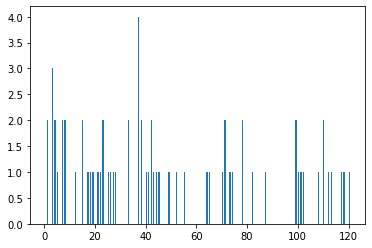

In [97]:
plt.hist(vhs_just_results['_q'],bins=np.arange(0.5,121,0.5))
plt.show()

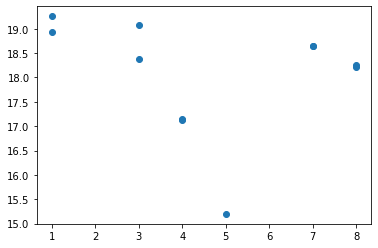

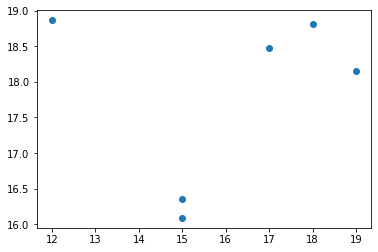

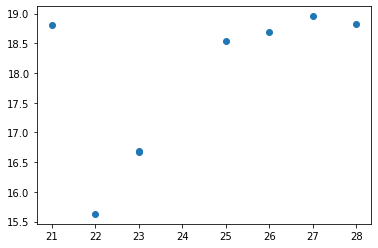

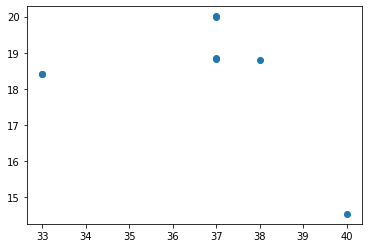

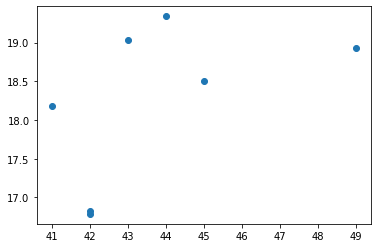

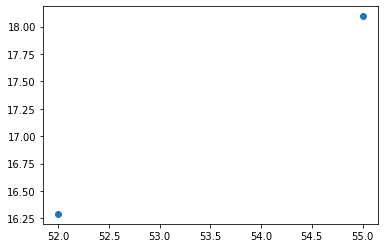

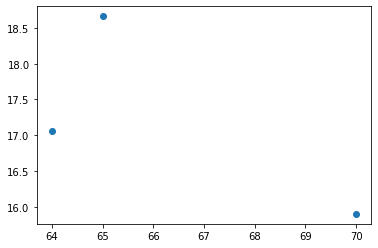

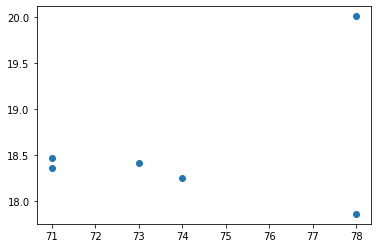

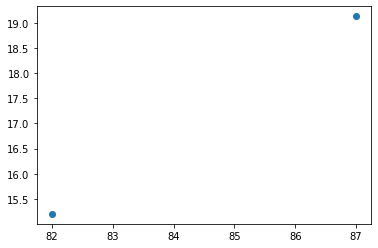

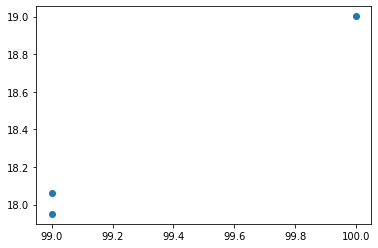

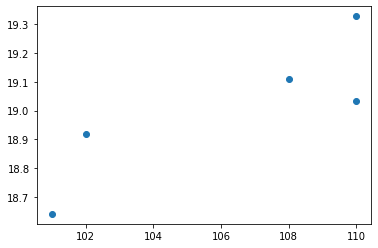

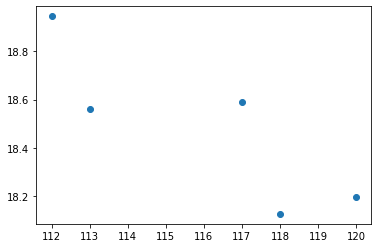

In [98]:
for val in np.arange(10,121,10):
    inbound=np.where((vhs_just_results["_q"]>val-10) & (vhs_just_results["_q"]<=val))
    plt.scatter(vhs_just_results["_q"][inbound],vhs_just_results["Jap3"][inbound])
    plt.show()

In [99]:
#for colname in vhs_just_results[np.where(vhs_just_results['_q']==78)].colnames:
#    print(vhs_just_results[np.where(vhs_just_results['_q']==78)][colname])

row_num=0
for row in vhs_just_results:
    try:
        printtime=Time(row['_tab1_36'],format='mjd')
        printtime.format='isot'
        print(row_num,'YMJD',row['_q'],printtime)
    except AttributeError:
        pass
    try:
        printtime=Time(row['_tab1_58'],format='mjd')
        printtime.format='isot'
        print(row_num,'JMJD',row['_q'],printtime)
    except AttributeError:
        pass
    row_num+=1
    
print(vhs_just_results[np.where(vhs_just_results['_q']==78)])
printtime=Time(vhs_just_results[np.where(vhs_just_results['_q']==78)]['_tab1_36'],format='mjd')
printtime.format='isot'
print(printtime)

0 YMJD 1 2016-09-24T02:29:29.357
0 JMJD 1 2016-09-24T02:20:22.186
1 YMJD 1 2016-09-24T02:56:14.496
1 JMJD 1 2016-09-24T02:47:17.606
2 JMJD 3 2013-08-10T07:23:27.571
3 JMJD 3 2013-08-10T07:22:32.534
5 JMJD 4 2012-12-23T03:29:24.806
6 JMJD 4 2012-12-31T02:58:51.658
7 JMJD 5 2011-11-13T06:49:26.630
8 JMJD 7 2013-06-05T10:07:30.346
9 JMJD 7 2013-06-26T09:10:10.070
10 JMJD 8 2016-11-09T04:27:50.832
11 JMJD 8 2016-11-09T04:47:05.050
12 JMJD 12 2016-12-16T05:21:28.714
13 YMJD 15 2015-10-14T06:38:58.330
13 JMJD 15 2015-10-14T06:30:30.643
14 JMJD 15 2015-10-14T06:30:30.643
15 JMJD 17 2013-12-09T06:38:10.982
16 JMJD 18 2014-11-06T03:54:07.171
17 YMJD 19 2017-01-02T03:26:33.907
17 JMJD 19 2017-01-02T03:18:19.181
18 JMJD 21 2016-01-28T03:53:49.978
19 YMJD 22 2017-01-12T04:09:55.930
19 JMJD 22 2017-01-12T04:01:39.648
20 JMJD 23 2016-08-20T07:49:31.066
21 JMJD 23 2016-08-18T09:44:04.963
22 JMJD 25 2014-01-11T05:06:47.779
23 JMJD 26 2013-01-06T05:50:26.218
24 JMJD 27 2015-01-07T03:23:14.237
25 JMJD 2

In [171]:
unique_index=np.unique(vhs_just_results["_q"])
#print(unique_index)

Ok, now we have to choose the closest match at this point I'm pretty sure. There were 18 double matches before. I think I'm going to just do the minimum distance from the position, BUT I'm going to propagate the positions to the epoch of the VHS observation I think... or I should just do this without that step... No we're just going to use the present coordinates and assume that they are either the same object anyway or the closest one is probably actually the right object.

coords_vhs_epoch #the 2013-ish Gaia DR3 coordinates for the MORDOR objects

In [101]:
vhs_results_coords=coord.SkyCoord(ra=vhs_just_results['RAJ2000'],dec=vhs_just_results['DEJ2000'])

In [185]:
separations=coords_vhs_epoch[vhs_just_results['_q']-1].separation(vhs_results_coords).to(u.arcsecond)

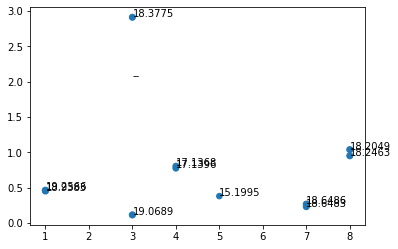

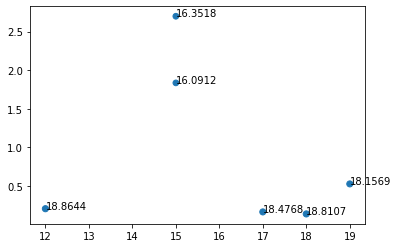

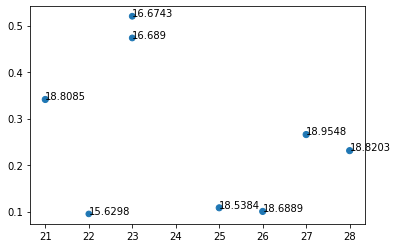

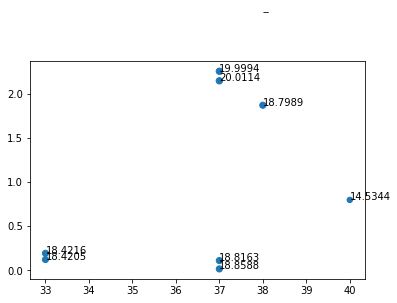

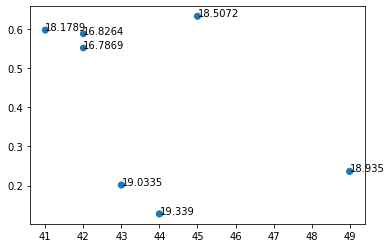

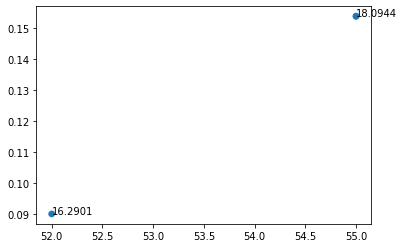

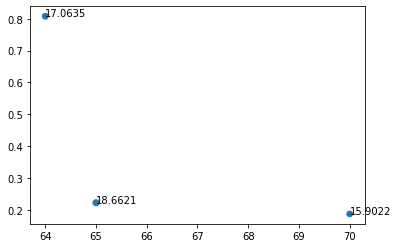

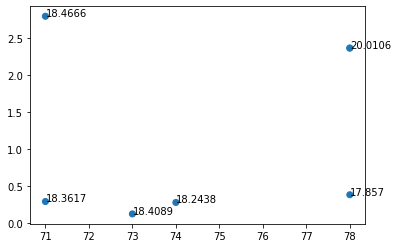

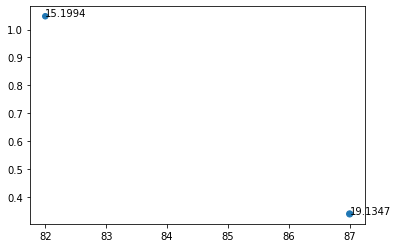

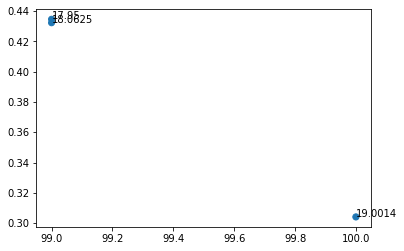

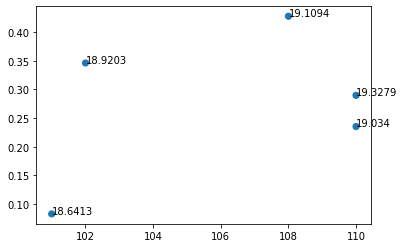

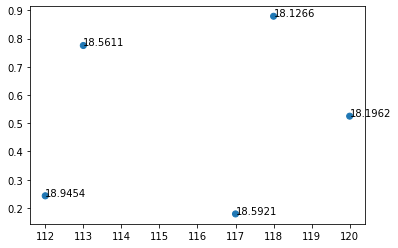

In [103]:
for val in np.arange(10,121,10):
    inbound=np.where((vhs_just_results["_q"]>val-10) & (vhs_just_results["_q"]<=val))
    plt.scatter(vhs_just_results['_q'][inbound],separations[inbound],s=vhs_just_results['Jap3'][inbound]*2)
    thiscount=0
    for row in vhs_just_results[inbound]:
        plt.text(row['_q'],separations[inbound][thiscount].value,str(row['Jap3']))
        thiscount+=1
    plt.show()


q 1 inbounds (array([0, 1]),)
 _q   Yap3    Jap3   Hap3 Ksap3
      mag     mag    mag   mag 
--- ------- -------- ---- -----
  1 19.2025  19.2566   --    -- [0.46402arcsec 0.454356arcsec]
 _q   Yap3    Jap3   Hap3 Ksap3
      mag     mag    mag   mag 
--- ------- -------- ---- -----
  1 19.2493  18.9383   --    -- [0.46402arcsec 0.454356arcsec]


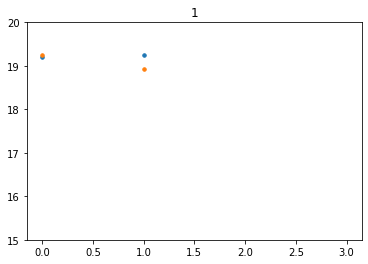

q 3 inbounds (array([2, 3, 4]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
  3   --  19.0689   --    -- [0.115497arcsec 2.91172arcsec 2.03831arcsec]
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
  3   --  18.3775   --  17.7405 [0.115497arcsec 2.91172arcsec 2.03831arcsec]
 _q Yap3 Jap3 Hap3  Ksap3  
    mag  mag  mag    mag   
--- ---- ---- ---- --------
  3   --   --   --  18.3360 [0.115497arcsec 2.91172arcsec 2.03831arcsec]


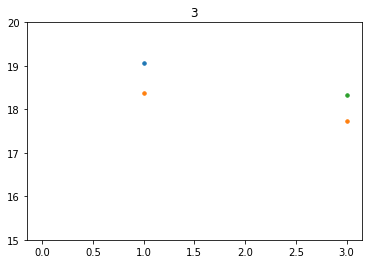

q 4 inbounds (array([5, 6]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
  4   --  17.1368   --  16.0771 [0.805078arcsec 0.776525arcsec]
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
  4   --  17.1396   --  16.0864 [0.805078arcsec 0.776525arcsec]


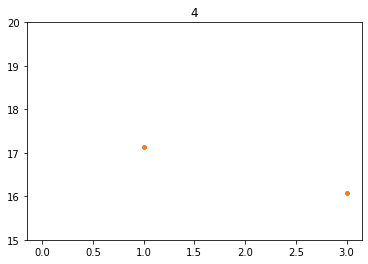

q 5 inbounds (array([7]),)
 _q Yap3   Jap3     Hap3    Ksap3  
    mag    mag      mag      mag   
--- ---- -------- -------- --------
  5   --  15.1995  14.7415  14.3451 [0.381339arcsec]


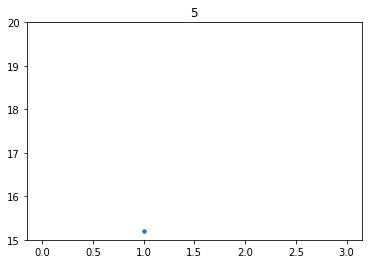

q 7 inbounds (array([8, 9]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
  7   --  18.6483   --    -- [0.232951arcsec 0.268006arcsec]
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
  7   --  18.6486   --    -- [0.232951arcsec 0.268006arcsec]


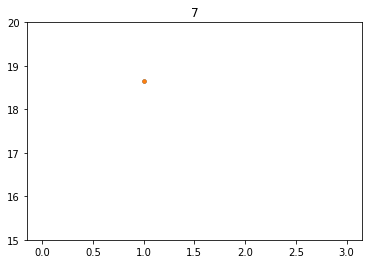

q 8 inbounds (array([10, 11]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
  8   --  18.2049   --  17.9331 [1.03937arcsec 0.951789arcsec]
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
  8   --  18.2463   --  18.0143 [1.03937arcsec 0.951789arcsec]


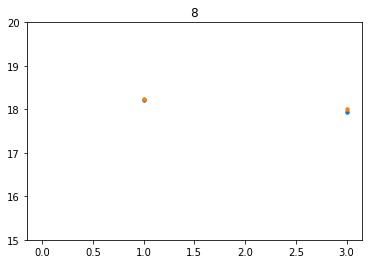

q 12 inbounds (array([12]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 12   --  18.8644   --  18.3982 [0.204837arcsec]


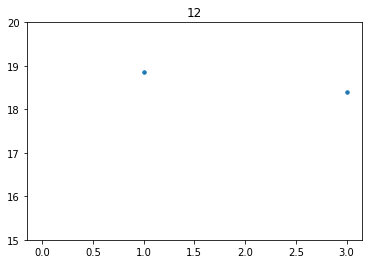

q 15 inbounds (array([13, 14]),)
 _q   Yap3    Jap3   Hap3 Ksap3
      mag     mag    mag   mag 
--- ------- -------- ---- -----
 15 16.4935  16.3518   --    -- [2.69977arcsec 1.8359arcsec]
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 15   --  16.0912   --  15.8424 [2.69977arcsec 1.8359arcsec]


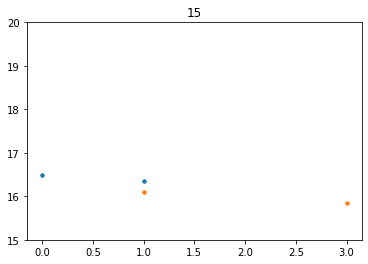

q 17 inbounds (array([15]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
 17   --  18.4768   --    -- [0.163211arcsec]


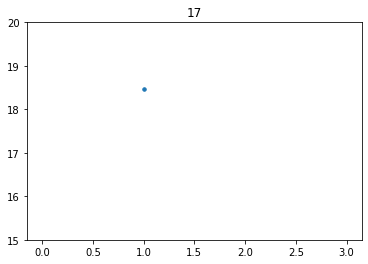

q 18 inbounds (array([16]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 18   --  18.8107   --  18.1291 [0.137246arcsec]


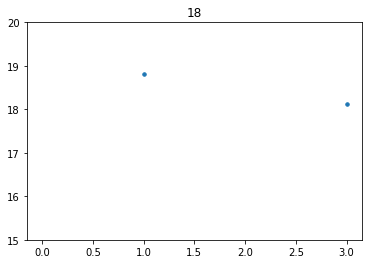

q 19 inbounds (array([17]),)
 _q   Yap3    Jap3   Hap3  Ksap3  
      mag     mag    mag    mag   
--- ------- -------- ---- --------
 19 18.5493  18.1569   --  17.1224 [0.526282arcsec]


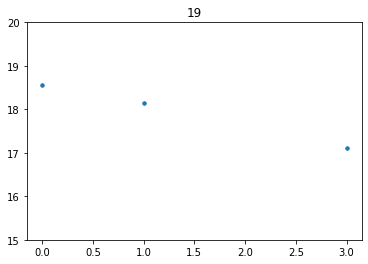

q 21 inbounds (array([18]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 21   --  18.8085   --  18.6121 [0.341079arcsec]


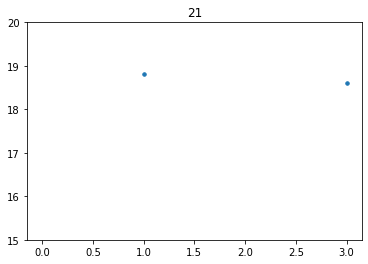

q 22 inbounds (array([19]),)
 _q   Yap3    Jap3   Hap3  Ksap3  
      mag     mag    mag    mag   
--- ------- -------- ---- --------
 22 16.5013  15.6298   --  14.7451 [0.0949142arcsec]


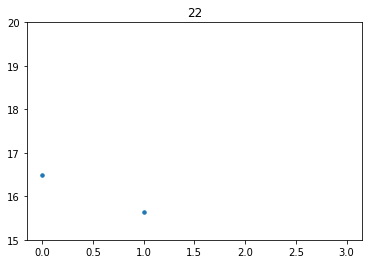

q 23 inbounds (array([20, 21]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 23   --  16.6743   --  15.8515 [0.520119arcsec 0.473436arcsec]
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 23   --  16.6890   --  15.9461 [0.520119arcsec 0.473436arcsec]


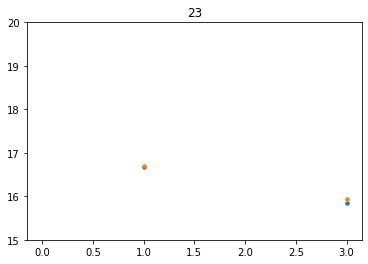

q 25 inbounds (array([22]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 25   --  18.5384   --  18.1358 [0.108087arcsec]


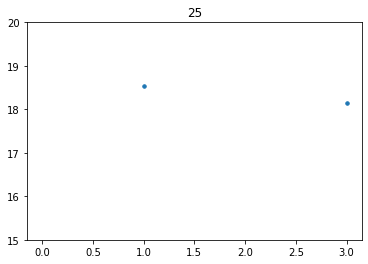

q 26 inbounds (array([23]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 26   --  18.6889   --  18.3470 [0.100261arcsec]


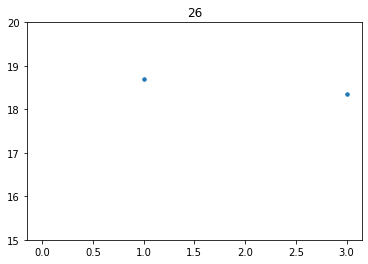

q 27 inbounds (array([24]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
 27   --  18.9548   --    -- [0.265629arcsec]


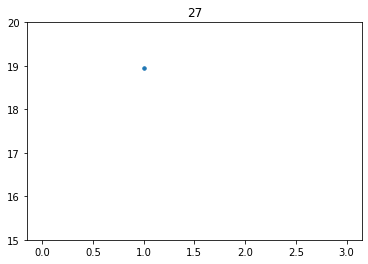

q 28 inbounds (array([25]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
 28   --  18.8203   --    -- [0.231023arcsec]


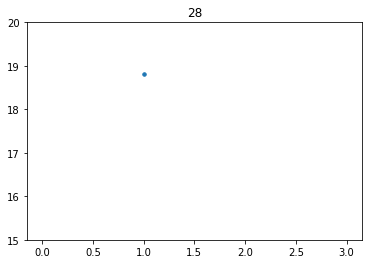

q 33 inbounds (array([26, 27]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 33   --  18.4216   --  17.6820 [0.191209arcsec 0.120205arcsec]
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 33   --  18.4205   --  17.5815 [0.191209arcsec 0.120205arcsec]


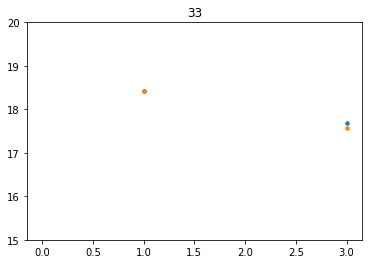

q 37 inbounds (array([28, 29, 30, 31]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
 37   --  20.0114   --    -- [2.14514arcsec 0.108339arcsec 0.0139743arcsec 2.25363arcsec]
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
 37   --  18.8163   --    -- [2.14514arcsec 0.108339arcsec 0.0139743arcsec 2.25363arcsec]
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
 37   --  18.8588   --    -- [2.14514arcsec 0.108339arcsec 0.0139743arcsec 2.25363arcsec]
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
 37   --  19.9994   --    -- [2.14514arcsec 0.108339arcsec 0.0139743arcsec 2.25363arcsec]


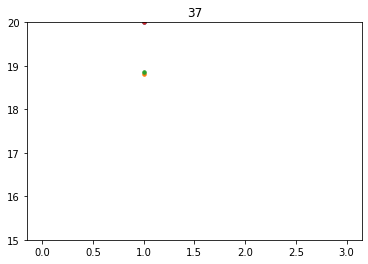

q 38 inbounds (array([32, 33]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
 38   --  18.7989   --    -- [1.86843arcsec 2.89373arcsec]
 _q Yap3 Jap3 Hap3  Ksap3  
    mag  mag  mag    mag   
--- ---- ---- ---- --------
 38   --   --   --  17.4902 [1.86843arcsec 2.89373arcsec]


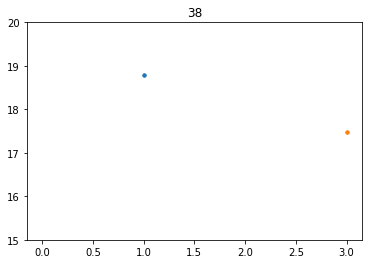

q 40 inbounds (array([34]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 40   --  14.5344   --  13.7251 [0.795725arcsec]


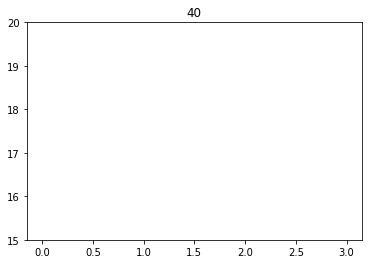

q 41 inbounds (array([35]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 41   --  18.1789   --  17.7200 [0.597444arcsec]


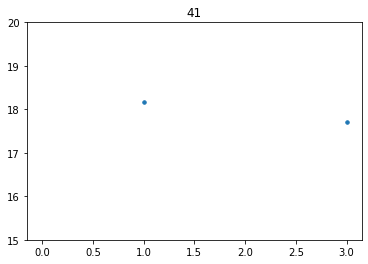

q 42 inbounds (array([36, 37]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 42   --  16.7869   --  15.8918 [0.551704arcsec 0.587787arcsec]
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 42   --  16.8264   --  16.0222 [0.551704arcsec 0.587787arcsec]


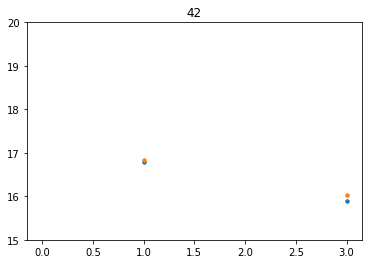

q 43 inbounds (array([38]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
 43   --  19.0335   --    -- [0.201465arcsec]


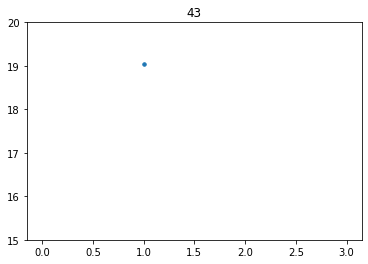

q 44 inbounds (array([39]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
 44   --  19.3390   --    -- [0.127641arcsec]


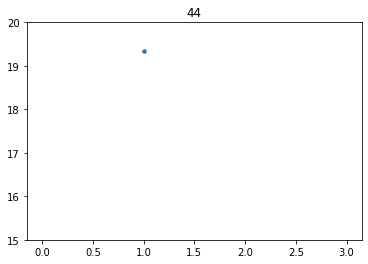

q 45 inbounds (array([40]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 45   --  18.5072   --  17.7188 [0.632798arcsec]


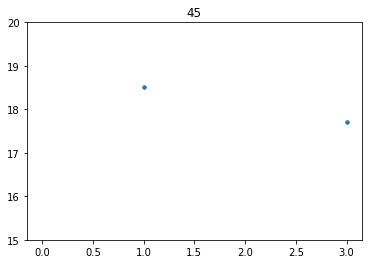

q 49 inbounds (array([41]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
 49   --  18.9350   --    -- [0.23623arcsec]


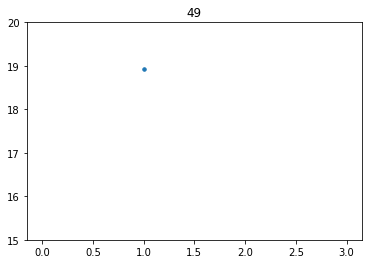

q 52 inbounds (array([42]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
 52   --  16.2901   --    -- [0.0900833arcsec]


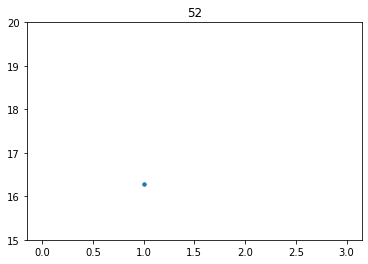

q 55 inbounds (array([43]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 55   --  18.0944   --  17.0608 [0.153857arcsec]


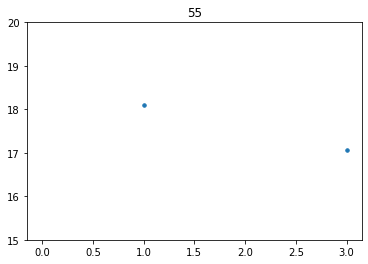

q 64 inbounds (array([44]),)
 _q   Yap3    Jap3   Hap3  Ksap3  
      mag     mag    mag    mag   
--- ------- -------- ---- --------
 64 17.2637  17.0635   --  17.3635 [0.807666arcsec]


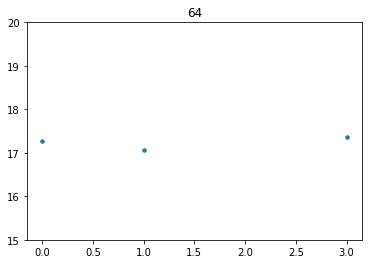

q 65 inbounds (array([45]),)
 _q   Yap3    Jap3     Hap3    Ksap3  
      mag     mag      mag      mag   
--- ------- -------- -------- --------
 65 19.0628  18.6621  18.3647  17.6855 [0.222256arcsec]


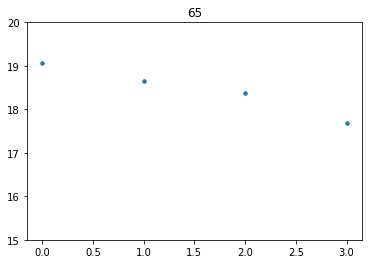

q 70 inbounds (array([46]),)
 _q   Yap3    Jap3   Hap3  Ksap3  
      mag     mag    mag    mag   
--- ------- -------- ---- --------
 70 16.6963  15.9022   --  14.9577 [0.187192arcsec]


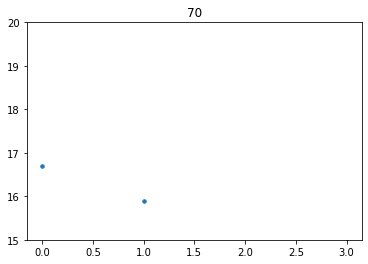

q 71 inbounds (array([47, 48]),)
 _q   Yap3    Jap3     Hap3    Ksap3  
      mag     mag      mag      mag   
--- ------- -------- -------- --------
 71 19.1111  18.4666  17.5041  16.7320 [2.78882arcsec 0.295676arcsec]
 _q   Yap3    Jap3     Hap3   Ksap3
      mag     mag      mag     mag 
--- ------- -------- -------- -----
 71 18.6891  18.3617  17.9289    -- [2.78882arcsec 0.295676arcsec]


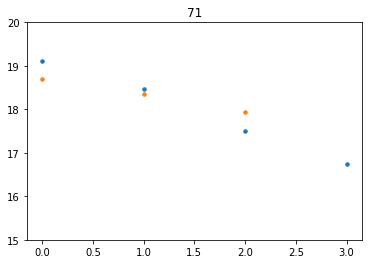

q 73 inbounds (array([49]),)
 _q   Yap3    Jap3   Hap3  Ksap3  
      mag     mag    mag    mag   
--- ------- -------- ---- --------
 73 18.7424  18.4089   --  17.9754 [0.128948arcsec]


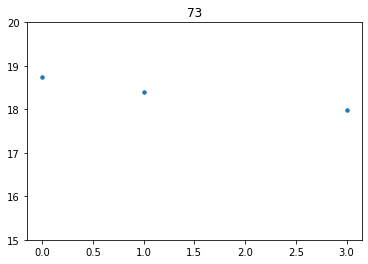

q 74 inbounds (array([50]),)
 _q   Yap3    Jap3   Hap3 Ksap3
      mag     mag    mag   mag 
--- ------- -------- ---- -----
 74 18.4940  18.2438   --    -- [0.283361arcsec]


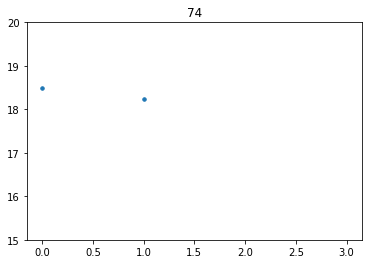

q 78 inbounds (array([51, 52]),)
 _q   Yap3    Jap3     Hap3   Ksap3
      mag     mag      mag     mag 
--- ------- -------- -------- -----
 78 18.1498  17.8570  17.6382    -- [0.386892arcsec 2.36053arcsec]
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
 78   --  20.0106   --    -- [0.386892arcsec 2.36053arcsec]


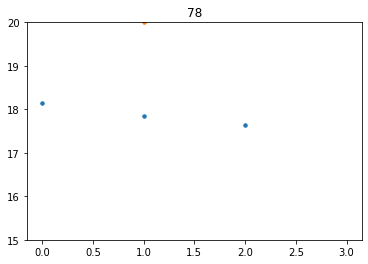

q 82 inbounds (array([53]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 82   --  15.1994   --  14.4376 [1.04792arcsec]


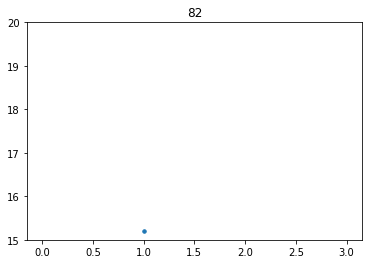

q 87 inbounds (array([54]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
 87   --  19.1347   --    -- [0.338749arcsec]


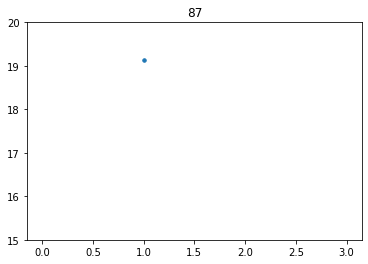

q 99 inbounds (array([55, 56]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 99   --  17.9500   --  16.7362 [0.434549arcsec 0.432218arcsec]
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
 99   --  18.0625   --  17.0301 [0.434549arcsec 0.432218arcsec]


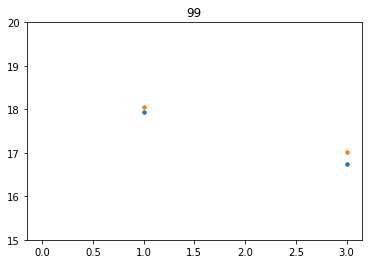

q 100 inbounds (array([57]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
100   --  19.0014   --    -- [0.304105arcsec]


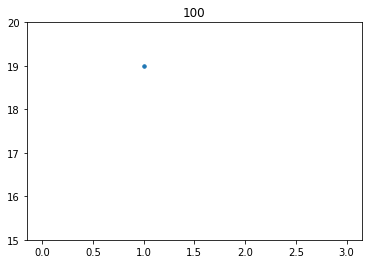

q 101 inbounds (array([58]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
101   --  18.6413   --    -- [0.0826783arcsec]


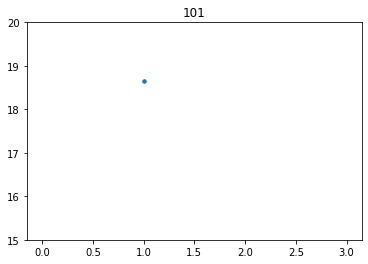

q 102 inbounds (array([59]),)
 _q Yap3   Jap3   Hap3 Ksap3
    mag    mag    mag   mag 
--- ---- -------- ---- -----
102   --  18.9203   --    -- [0.346281arcsec]


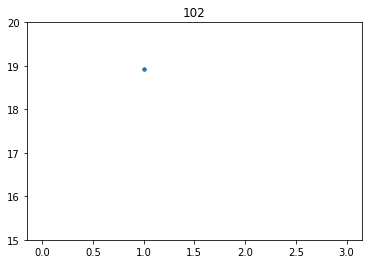

q 108 inbounds (array([60]),)
 _q   Yap3    Jap3   Hap3 Ksap3
      mag     mag    mag   mag 
--- ------- -------- ---- -----
108 19.1218  19.1094   --    -- [0.427906arcsec]


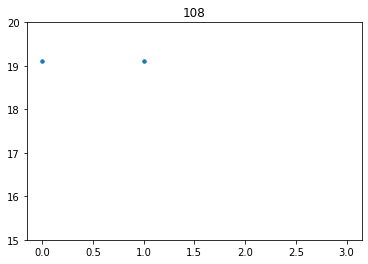

q 110 inbounds (array([61, 62]),)
 _q   Yap3    Jap3   Hap3 Ksap3
      mag     mag    mag   mag 
--- ------- -------- ---- -----
110 19.4112  19.0340   --    -- [0.235306arcsec 0.28976arcsec]
 _q   Yap3    Jap3   Hap3 Ksap3
      mag     mag    mag   mag 
--- ------- -------- ---- -----
110 19.2279  19.3279   --    -- [0.235306arcsec 0.28976arcsec]


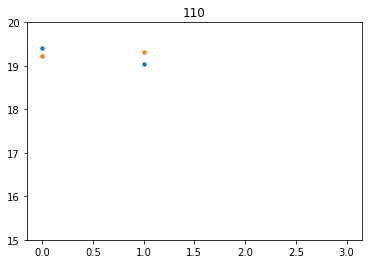

q 112 inbounds (array([63]),)
 _q Yap3   Jap3   Hap3  Ksap3  
    mag    mag    mag    mag   
--- ---- -------- ---- --------
112   --  18.9454   --  18.5502 [0.242876arcsec]


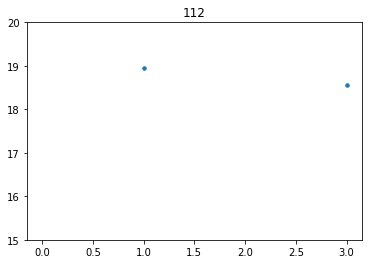

q 113 inbounds (array([64]),)
 _q Yap3   Jap3     Hap3    Ksap3  
    mag    mag      mag      mag   
--- ---- -------- -------- --------
113   --  18.5611  18.4598  18.5669 [0.775679arcsec]


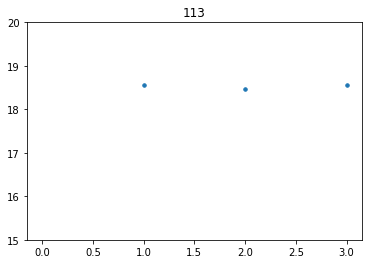

q 117 inbounds (array([65]),)
 _q   Yap3    Jap3   Hap3 Ksap3
      mag     mag    mag   mag 
--- ------- -------- ---- -----
117 18.8407  18.5921   --    -- [0.178683arcsec]


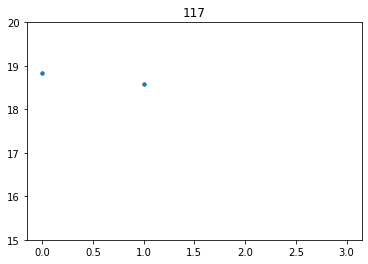

q 118 inbounds (array([66]),)
 _q Yap3   Jap3     Hap3    Ksap3  
    mag    mag      mag      mag   
--- ---- -------- -------- --------
118   --  18.1266  17.5869  17.1441 [0.879398arcsec]


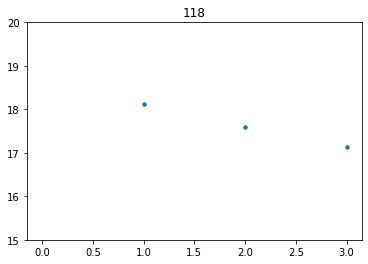

q 120 inbounds (array([67]),)
 _q   Yap3    Jap3   Hap3  Ksap3  
      mag     mag    mag    mag   
--- ------- -------- ---- --------
120 18.4524  18.1962   --  17.9782 [0.525223arcsec]


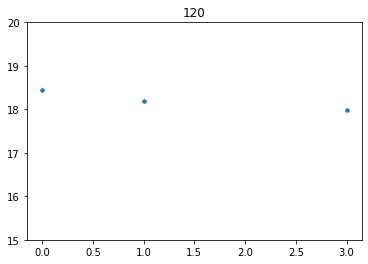

In [186]:
for q in unique_index:
    inbounds=np.where(vhs_just_results['_q']==q)#find all rows of VHS results that went to the same row
    print('q',q,'inbounds',inbounds)
    if inbounds[0].shape[0]>0.1: #using a greater than integer value to ensure we don't have weird data type issues
        #min_index=np.argmin(separations[inbounds].value)
        #print(min_index)
        #need to pull out this row and then stick it onto the table I should have been building
        for row in vhs_just_results[inbounds]:
            print(row['_q','Yap3','Jap3','Hap3','Ksap3'],separations[inbounds])
            plt.scatter([0,1,2,3],np.hstack(row['Yap3','Jap3','Hap3','Ksap3']),s=12)
        plt.title(str(q))
        plt.ylim(15,20)
        plt.show()
    else:
        pass


In [104]:
collected_results=[]
for q in unique_index:
    inbounds=np.where(vhs_just_results['_q']==q)#find all rows of VHS results that went to the same row
    print('q',q,'inbounds',inbounds)
    if inbounds[0].shape[0]>1.1: #using a greater than integer value to ensure we don't have weird data type issues
        min_index=np.argmin(separations[inbounds].value)
        #print(min_index)
        #need to pull out this row and then stick it onto the table I should have been building
        print(vhs_just_results[inbounds])
        good_row=vhs_just_results[inbounds][min_index]
        collected_results.append(good_row)
    else:
        collected_results.append(vhs_just_results[inbounds])
        
collected_table=vstack(collected_results)
collected_table.pprint()

q 1 inbounds (array([0, 1]),)
 _q    SrcID      RAJ2000    DEJ2000   Mclass ... e_Hap3 _tab1_106 Ksap3 e_Ksap3
                    deg        deg            ...  mag       d      mag    mag  
--- ------------ ---------- ---------- ------ ... ------ --------- ----- -------
  1 472892241765   2.123992 -24.081852     -1 ...     --        --    --      --
  1 472988065607   2.123990 -24.081847     -1 ...     --        --    --      --
q 3 inbounds (array([2, 3, 4]),)
 _q    SrcID      RAJ2000    DEJ2000   ... e_Hap3  _tab1_106    Ksap3   e_Ksap3
                    deg        deg     ...  mag        d         mag      mag  
--- ------------ ---------- ---------- ... ------ ------------ -------- -------
  3 472561753936  17.509244 -59.444449 ...     --           --       --      --
  3 472561753937  17.510528 -59.444886 ...     -- 56514.298288  17.7405  0.1252
  3 472561766659  17.509387 -59.443857 ...     -- 56514.298658  18.3360  0.2159
q 4 inbounds (array([5, 6]),)
 _q    SrcID      RAJ2

Now adding the DR2 source id onto those results so eventually it can be joined to the mega table; also renaming the columns to have vhs in them and making the nonsense names be actual mjd like they were supposed to be

In [105]:
collected_table.rename_column('_tab1_36','YMJD')
collected_table.rename_column('_tab1_58','JMJD')
collected_table.rename_column('_tab1_82','HMJD')
collected_table.rename_column('_tab1_106','KsMJD')
for colname in collected_table.colnames[1:]:
    #print(galex_just_results[colname])
    collected_table.rename_column(colname,"vhs_"+colname.lower())

In [106]:
collected_table['dr2_source_id']=Column(np.empty(len(collected_table)),dtype=np.int64,name='dr2_source_id')
collected_table['dr2_source_id']=fulldr3_results[collected_table['_q']-1]['dr2_source_id']

In [144]:
vhs_final_results=collected_table
vhs_final_results.remove_column('_q')
vhs_final_results.pprint()

 vhs_srcid   vhs_raj2000 vhs_dej2000 ... vhs_e_ksap3    dr2_source_id   
                 deg         deg     ...     mag                        
------------ ----------- ----------- ... ----------- -------------------
472988065607    2.123990  -24.081847 ...          -- 2336521827465439616
472561753936   17.509244  -59.444449 ...          -- 4909222871450620416
473801277819   17.551656  -56.010244 ...      0.0257 4913565903725184640
472899540255   21.693842  -47.119023 ...      0.0073 4930805868092016256
472910962864   23.899556  -63.115793 ...          -- 4712157368044092928
473735631531   25.188333  -18.391631 ...      0.1531 5140433498003756160
473060120168   42.002380  -15.933686 ...      0.2258 5156753037993200512
472551520095   49.753390  -73.989079 ...      0.0259 4641329405963444608
473757854808   52.437741  -43.101782 ...          -- 4849260661232437504
473361364202   53.580920  -63.806510 ...      0.1796 4673772519470806144
         ...         ...         ... ...         ..

Ok. vhs_final_results is the table that contains the ready to go table for joining to make the mega table

## I suppose I should also get UKIDSS to complement the VHS data, right? I'm pretty sure UKIDSS is northern?

Ok, so UKIDSS data. Is UKIDSS one of the Gaia default joins? Nope. Not in Gaia DR3. Nor in DR2. And I checked eDR3 even though there's no reason it should have additional crossmatches and it doesn't have UKIDSS either. So looks like we're going the VHS route. Yay.

UKIDSS survey overall ADS link: https://ui.adsabs.harvard.edu/abs/2007MNRAS.379.1599L/abstract

We're going to use UKIDSS DR9, which is the last one as far as I can tell: https://ui.adsabs.harvard.edu/abs/2013yCat.2319....0L/abstract

http://vizier.cds.unistra.fr/viz-bin/VizieR?-source=II/319/las9

ukidss_cols=[
    'RAJ2000',
    'DEJ2000',
    'm',
    'Ymag',
    'e_Ymag',
    'Jmag1',
    'e_Jmag1',
    'Jmag2',
    'e_Jmag2',
    'Hmag',
    'e_Hmag',
    'Kmag',
    'Kmag'
    
    
]

Actually I think we just want all of the column names having looked at them now. They all seem like things we'd want to bring out, to include the proper motions from UKIDSS.

In [121]:
ukidss_search_rad=7.0*u.arcsecond

In [122]:
ukidss_cat_name='II/319/las9'
ukidss_epoch=Time('2008.7484',format='jyear',scale='tcb') #based on the MORDOR object with UKIDSS photometry. It is included for each entry so we can check it once we ru nthis

In [123]:
coords_ukidss_epoch=dr3_coords.apply_space_motion(ukidss_epoch)

In [124]:
vizier_ukidss=Vizier(catalog=ukidss_cat_name)

In [125]:
ukidss_results=vizier_ukidss.query_region(coords_ukidss_epoch,radius=ukidss_search_rad)

In [126]:
ukidss_just_results=ukidss_results[0]

In [127]:
ukidss_just_results.pprint()

 _q         ULAS         m   RAJ2000   ...  _tab1_18   pmRA     pmDE    cl
                               deg     ...     yr    mas / yr mas / yr    
--- ------------------- --- ---------- ... --------- -------- -------- ---
  9 J021136.17+083528.5   1  32.900744 ... 2010.7487       --       --  -2
 48 J081553.52+242734.7   1 123.973024 ... 2008.3333     82.6    -56.3  -1
 50 J082408.71+270535.5   1 126.036306 ... 2009.1302       --       --  -1
 58 J113115.63+054312.4   1 172.815153 ... 2009.9513   -545.4    -29.2  -1
 60 J115901.15+003536.0   1 179.754832 ... 2008.3200       --       --   1
 60 J115900.91+003539.6   1 179.753792 ... 2008.3200       --       --  -1
 60 J115901.08+003545.7   1 179.754514 ... 2008.3200       --       --  -3
 61 J115907.76+103939.0   2 179.782361 ... 2010.1056       --       --   0
 61 J115907.76+103939.3   2 179.782368 ... 2010.0782       --       --  -1
 61 J115907.77+103939.5   1 179.782405 ... 2007.7076      9.7      2.2  -1
 61 J115907.96+103943.8  

In [128]:
for name in ukidss_just_results.colnames:
    print(name)

_q
ULAS
m
RAJ2000
DEJ2000
Ymag
e_Ymag
Jmag1
e_Jmag1
Jmag2
e_Jmag2
Hmag
e_Hmag
Kmag
e_Kmag
_tab1_18
pmRA
pmDE
cl


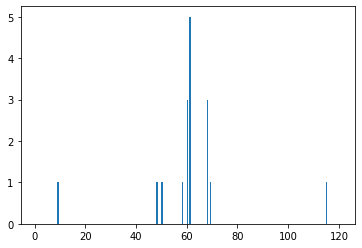

In [129]:
plt.hist(ukidss_just_results['_q'],bins=np.arange(0.5,121,0.5))
plt.show()

In [187]:
ukidss_results_coords=coord.SkyCoord(ra=ukidss_just_results['RAJ2000'],dec=ukidss_just_results['DEJ2000'])
separations=coords_ukidss_epoch[ukidss_just_results['_q']-1].separation(ukidss_results_coords).to(u.arcsecond)

ValueError: need at least one array to concatenate

<Figure size 432x288 with 1 Axes>

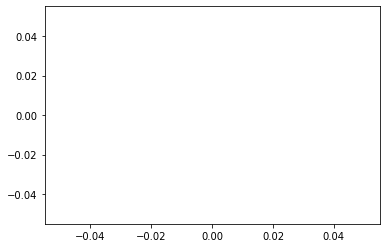

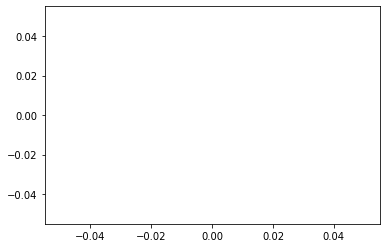

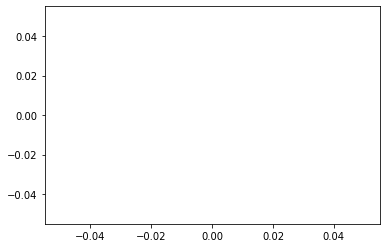

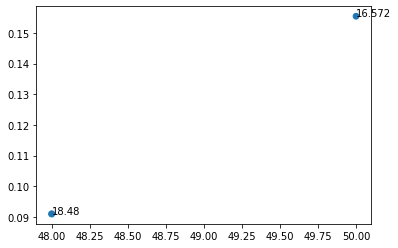

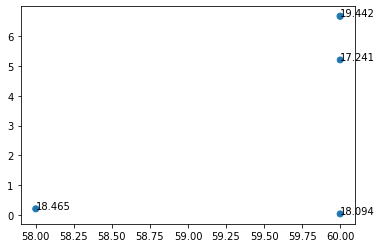

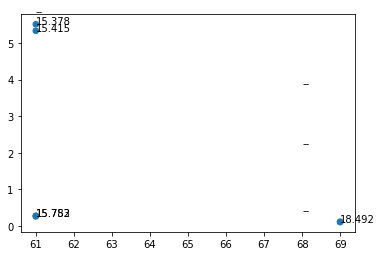

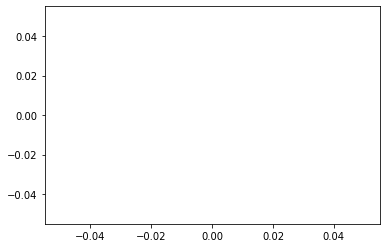

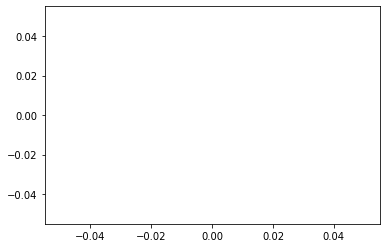

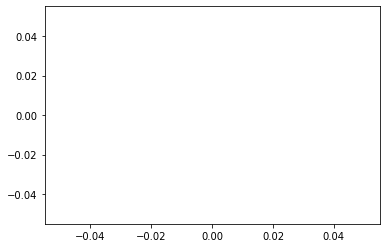

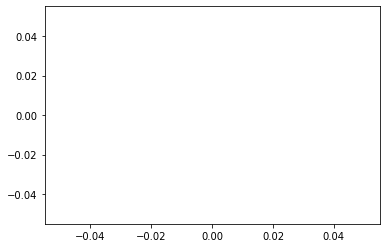

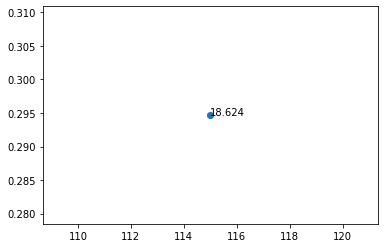

In [138]:
for val in np.arange(10,121,10):
    inbound=np.where((ukidss_just_results["_q"]>val-10) & (ukidss_just_results["_q"]<=val))
    plt.scatter(ukidss_just_results['_q'][inbound],separations[inbound],s=ukidss_just_results['Jmag1'][inbound]*2)
    thiscount=0
    for row in ukidss_just_results[inbound]:
        plt.text(row['_q'],separations[inbound][thiscount].value,str(row['Jmag1']))
        thiscount+=1
    plt.show()



In [130]:
unique_matches=np.unique(ukidss_just_results['_q'])

In [133]:
print(len(unique_matches))

9


So there are only 9 UKIDSS matches... that seems... low... It appears DR9 includes the LAS, GCS, and DXS, but the only one they mention for area is the LAS which is listed as 4000 square degrees. However the 2007 paper describes UKIDSS as a 7000 square degrees survey covering just the LaS GCS and Galactic plane survey. So I guess DR9 doesn't include the galactic plane?

Ah the UKIDSS webpage describes the surveys. http://ukidss.org/surveys/surveys.html

LAS = 3792 sq deg K=18.2

GPS= 1851 sq deg K=18.6

GCS= 1069 sq deg K=18.6

DXS= 31 sq deg K=20.8

UDS = 0.77 sq deg K=22.8

And looking at the plot of the RAs and Dec coverage of UKIDSS on-sky, it actually does look like there's a lot of missed sky, so maybe it's not so far-fetched that we only got 9 unique cross matches.

So now we need to correctly narrow down these matches... like we did with VHS.

So that's where I'll need to pick back up.

Also, I need to rename the columns to match the convention of the others. To include renaming of error columns to match Gaia's convention I think.

q 9 inbounds (array([0]),)
 _q Ymag Jmag1 Jmag2  Hmag   Kmag 
    mag   mag   mag   mag    mag  
--- ---- ----- ----- ------ ------
  9   --    --    -- 17.609 17.417 [0.609034arcsec]


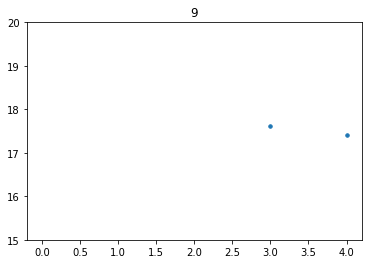

q 48 inbounds (array([1]),)
 _q  Ymag   Jmag1  Jmag2   Hmag   Kmag 
     mag     mag    mag    mag    mag  
--- ------ ------- ------ ------ ------
 48 18.764  18.480 18.495 18.626 18.370 [0.0910055arcsec]


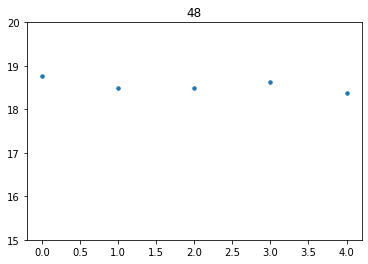

q 50 inbounds (array([2]),)
 _q  Ymag   Jmag1  Jmag2  Hmag   Kmag 
     mag     mag    mag   mag    mag  
--- ------ ------- ----- ------ ------
 50 17.455  16.572    -- 16.059 15.529 [0.15542arcsec]


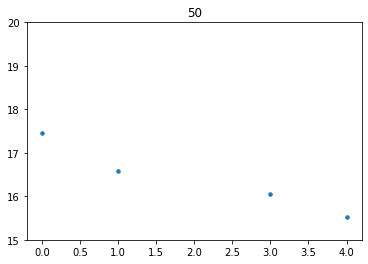

q 58 inbounds (array([3]),)
 _q  Ymag   Jmag1  Jmag2  Hmag  Kmag
     mag     mag    mag   mag   mag 
--- ------ ------- ----- ------ ----
 58 18.708  18.465    -- 18.449   -- [0.209387arcsec]


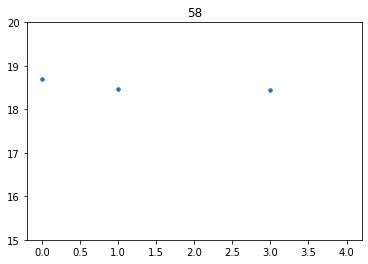

q 60 inbounds (array([4, 5, 6]),)
 _q  Ymag   Jmag1  Jmag2  Hmag   Kmag 
     mag     mag    mag   mag    mag  
--- ------ ------- ----- ------ ------
 60 17.847  17.241    -- 16.510 15.877 [5.20115arcsec 0.0393734arcsec 6.66511arcsec]
 _q  Ymag   Jmag1  Jmag2  Hmag   Kmag 
     mag     mag    mag   mag    mag  
--- ------ ------- ----- ------ ------
 60 18.438  18.094    -- 18.121 17.760 [5.20115arcsec 0.0393734arcsec 6.66511arcsec]
 _q Ymag  Jmag1  Jmag2  Hmag  Kmag
    mag    mag    mag   mag   mag 
--- ---- ------- ----- ------ ----
 60   --  19.442    -- 18.583   -- [5.20115arcsec 0.0393734arcsec 6.66511arcsec]


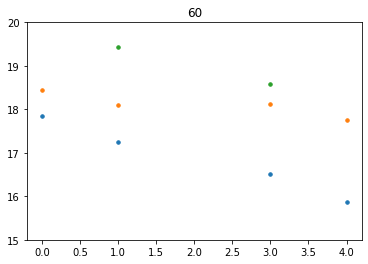

q 61 inbounds (array([ 7,  8,  9, 10, 11]),)
 _q Ymag Jmag1 Jmag2 Hmag  Kmag 
    mag   mag   mag  mag   mag  
--- ---- ----- ----- ---- ------
 61   --    --    --   -- 15.136 [5.78arcsec 5.508arcsec 5.3296arcsec 0.265916arcsec 0.284786arcsec]
 _q  Ymag   Jmag1  Jmag2  Hmag   Kmag 
     mag     mag    mag   mag    mag  
--- ------ ------- ----- ------ ------
 61 15.878  15.378    -- 14.828 14.558 [5.78arcsec 5.508arcsec 5.3296arcsec 0.265916arcsec 0.284786arcsec]
 _q  Ymag   Jmag1  Jmag2  Hmag   Kmag 
     mag     mag    mag   mag    mag  
--- ------ ------- ----- ------ ------
 61 15.935  15.415    -- 14.847 14.595 [5.78arcsec 5.508arcsec 5.3296arcsec 0.265916arcsec 0.284786arcsec]
 _q  Ymag   Jmag1  Jmag2  Hmag   Kmag 
     mag     mag    mag   mag    mag  
--- ------ ------- ----- ------ ------
 61 16.572  15.752    -- 15.149 14.620 [5.78arcsec 5.508arcsec 5.3296arcsec 0.265916arcsec 0.284786arcsec]
 _q  Ymag   Jmag1  Jmag2  Hmag   Kmag 
     mag     mag    mag   mag    mag  
--- -

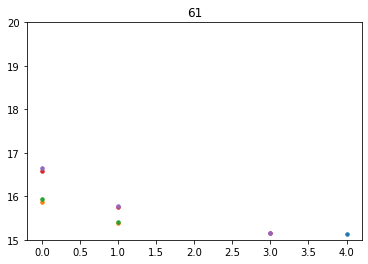

q 68 inbounds (array([12, 13, 14]),)
 _q  Ymag  Jmag1 Jmag2 Hmag Kmag
     mag    mag   mag  mag  mag 
--- ------ ----- ----- ---- ----
 68 20.363    --    --   --   -- [2.17672arcsec 0.34579arcsec 3.81771arcsec]
 _q  Ymag  Jmag1 Jmag2 Hmag Kmag
     mag    mag   mag  mag  mag 
--- ------ ----- ----- ---- ----
 68 18.828    --    --   --   -- [2.17672arcsec 0.34579arcsec 3.81771arcsec]
 _q  Ymag  Jmag1 Jmag2 Hmag Kmag
     mag    mag   mag  mag  mag 
--- ------ ----- ----- ---- ----
 68 20.310    --    --   --   -- [2.17672arcsec 0.34579arcsec 3.81771arcsec]


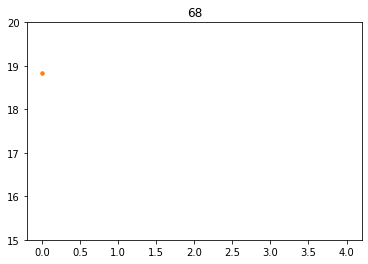

q 69 inbounds (array([15]),)
 _q  Ymag   Jmag1  Jmag2  Hmag  Kmag
     mag     mag    mag   mag   mag 
--- ------ ------- ----- ------ ----
 69 18.766  18.492    -- 18.304   -- [0.115485arcsec]


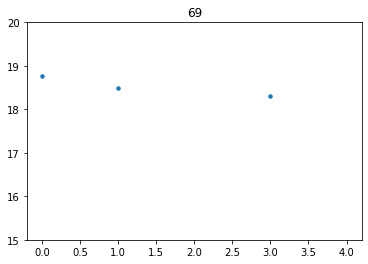

q 115 inbounds (array([16]),)
 _q  Ymag   Jmag1  Jmag2  Hmag  Kmag
     mag     mag    mag   mag   mag 
--- ------ ------- ----- ------ ----
115 18.994  18.624    -- 18.434   -- [0.294695arcsec]


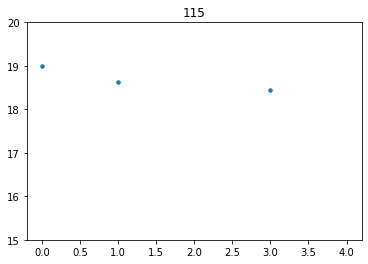

In [189]:
for q in unique_matches:
    inbounds=np.where(ukidss_just_results['_q']==q)#find all rows of VHS results that went to the same row
    print('q',q,'inbounds',inbounds)
    if inbounds[0].shape[0]>0.1: #using a greater than integer value to ensure we don't have weird data type issues
        #min_index=np.argmin(separations[inbounds].value)
        #print(min_index)
        #need to pull out this row and then stick it onto the table I should have been building
        for row in ukidss_just_results[inbounds]:
            print(row['_q','Ymag','Jmag1','Jmag2','Hmag','Kmag'],separations[inbounds])
            plt.scatter([0,1,2,3,4],np.hstack(row['Ymag','Jmag1','Jmag2','Hmag','Kmag']),s=12)
        plt.title(str(q))
        plt.ylim(15,20)
        plt.show()
    else:
        pass



Ok, I have now verified that UKIDSS also does in fact have the best target chosen at each search location by manually going through those above, and none of the double matches actually have more photometric points than each other. So my method is fine.

In [193]:
ukidss_collected_results=[]
for q in unique_matches:
    inbounds=np.where(ukidss_just_results['_q']==q)
    print('q',q,'inbounds',inbounds)
    if inbounds[0].shape[0]>1.1:
        min_index=np.argmin(separations[inbounds].value)
        print(ukidss_just_results[inbounds])
        good_row=ukidss_just_results[inbounds][min_index]
        print(good_row['_q','Ymag','Jmag1','Jmag2','Hmag','Kmag'],separations[inbounds][min_index])


        ukidss_collected_results.append(good_row)
    else:
        print(ukidss_just_results[inbounds]['_q','Ymag','Jmag1','Jmag2','Hmag','Kmag'],separations[inbounds])
        ukidss_collected_results.append(ukidss_just_results[inbounds])

collected_ukidss_table=vstack(ukidss_collected_results)
collected_ukidss_table.pprint()

q 9 inbounds (array([0]),)
 _q Ymag Jmag1 Jmag2  Hmag   Kmag 
    mag   mag   mag   mag    mag  
--- ---- ----- ----- ------ ------
  9   --    --    -- 17.609 17.417 [0.609034arcsec]
q 48 inbounds (array([1]),)
 _q  Ymag   Jmag1  Jmag2   Hmag   Kmag 
     mag     mag    mag    mag    mag  
--- ------ ------- ------ ------ ------
 48 18.764  18.480 18.495 18.626 18.370 [0.0910055arcsec]
q 50 inbounds (array([2]),)
 _q  Ymag   Jmag1  Jmag2  Hmag   Kmag 
     mag     mag    mag   mag    mag  
--- ------ ------- ----- ------ ------
 50 17.455  16.572    -- 16.059 15.529 [0.15542arcsec]
q 58 inbounds (array([3]),)
 _q  Ymag   Jmag1  Jmag2  Hmag  Kmag
     mag     mag    mag   mag   mag 
--- ------ ------- ----- ------ ----
 58 18.708  18.465    -- 18.449   -- [0.209387arcsec]
q 60 inbounds (array([4, 5, 6]),)
 _q         ULAS         m   RAJ2000   ...  _tab1_18   pmRA     pmDE    cl
                               deg     ...     yr    mas / yr mas / yr    
--- ------------------- --- -----

Ok, running that just based on minimum separation appears to have maybe mismatched some of those objects... notably q=61 (target list 760, SDSS J1159+1039) has pmra=-150, pmdec=-32 from Gaia DR3, which appears to have basically matched the ukidss pmra and pmdec of the object that wasn't matched. However, they seem to have the exact same Jmag so... I guess I'll just keep going

In [140]:
collected_ukidss_table.rename_column('_tab1_18','MJD')
for colname in collected_ukidss_table.colnames[1:]:
    collected_ukidss_table.rename_column(colname,'ukidss_'+colname.lower())

In [141]:
collected_ukidss_table['dr2_source_id']=Column(np.empty(len(collected_ukidss_table)),dtype=np.int64,name='dr2_source_id')
collected_ukidss_table['dr2_source_id']=fulldr3_results[collected_ukidss_table['_q']-1]['dr2_source_id']

In [143]:
ukidss_final_results=collected_ukidss_table
ukidss_final_results.remove_column('_q')
ukidss_final_results.pprint()

    ukidss_ulas     ukidss_m ukidss_raj2000 ... ukidss_cl    dr2_source_id   
                                  deg       ...                              
------------------- -------- -------------- ... --------- -------------------
J021136.17+083528.5        1      32.900744 ...        -2 2521858084423378176
J081553.52+242734.7        1     123.973024 ...        -1  679275191263785984
J082408.71+270535.5        1     126.036306 ...        -1  683016588814929280
J113115.63+054312.4        1     172.815153 ...        -1 3813412234172867200
J115900.91+003539.6        1     179.753792 ...        -1 3891194534285644160
J115907.96+103943.8        2     179.783194 ...        -1 3918451500552407552
J134258.81+033159.1        1     205.745062 ...         1 3713442266153553280
J135437.59+305911.0        1     208.656658 ...        -1 1457074561475495808
J230940.47+095917.2        1     347.418629 ...        -1 2714432598227069824


## SkyMapper photometry?

## DES photometry?

## DECaPS Photometry

## Making the Mega Table by Rejoining all of these disparate pieces and then cleaning up the result to not have ten thousand "dr2_source_id" values kicking around in there.

So tables that need to be included in this join are the following:

-DR2 original table with names - input_table - this needs to have columns removed still though...

-DR3 table of new values - fulldr3_results - I think this one is perfect as is, essentially

-PanSTARRS table - results_ps1_id - I think this one is good as is

-2MASS table - results_tmass_id - I think this one is good as is

-SDSS table - results_sdss_id

-GALEX table - galex_just_results - I think I've fixed this one to be ready to go

-VHS table- vhs_final_results- I think this one is ready to go

-UKIDSS table - ukidss_final_results - I am confident this one is ready to go

In [150]:
first_colnames=[
    'name',
    'designation',
    'source_id',
    'gf19',
    'pwd',
    'f_pwd',
    'sp_type',
    'sed_sp_type' 
]

In [151]:
start_table=input_table[first_colnames]

In [152]:
start_table.pprint()

       name                 designation           ... sp_type sed_sp_type
----------------- ------------------------------- ... ------- -----------
MORDOR J0008-2404 b'Gaia DR2 2336521827465439616' ...      DC           4
  SDSS J0049+2244 b'Gaia DR2 2802321579156605568' ...      DC           4
MORDOR J0110-5926 b'Gaia DR2 4909222871450620416' ...      DC          --
MORDOR J0110-5600 b'Gaia DR2 4913565903725184640' ...    WDdM          --
MORDOR J0126-4707 b'Gaia DR2 4930805868092016256' ...    WDdM          --
  SDSS J0132+1823 b'Gaia DR2 2593774421282488832' ...    WDdM           3
MORDOR J0135-6306 b'Gaia DR2 4712157368044092928' ...      DC          --
       LEHPM 1774 b'Gaia DR2 5140433498003756160' ...   DQpec           4
  LSPM J0211+0835 b'Gaia DR2 2521858084423378176' ...      DC           4
MORDOR J0225-3312 b'Gaia DR2 4967454759604815360' ...      DC          --
              ...                             ... ...     ...         ...
MORDOR J2126-7502 b'Gaia DR2 636890705

In [157]:
start_table.rename_column('source_id','dr2_source_id')

In [158]:
mega_table=join(start_table,fulldr3_results,join_type='left',keys='dr2_source_id')

In [159]:
mega_table.pprint()

       name                 designation           ... libname_gspphot
                                                  ...                
----------------- ------------------------------- ... ---------------
MORDOR J0325+1236   b'Gaia DR2 17497872857713920' ...                
MORDOR J0349+1241   b'Gaia DR2 37101100029189376' ...                
  LSPM J0253+2135  b'Gaia DR2 109336535778050944' ...                
  SDSS J0447+2430  b'Gaia DR2 147065972342145152' ...                
MORDOR J0447+8026  b'Gaia DR2 556697752349562112' ...                
MORDOR J0244+8145  b'Gaia DR2 568855743906926976' ...                
  ULAS J0815+2427  b'Gaia DR2 679275191263785984' ...                
  SDSS J0824+2705  b'Gaia DR2 683016588814929280' ...                
  SDSS J1040+3936  b'Gaia DR2 779233790504599168' ...                
  SDSS J1125+4453  b'Gaia DR2 784551196240140928' ...                
              ...                             ... ...             ...
MORDOR J2126-7502 b'

In [194]:
for name in mega_table.colnames:
    print(name)

name
designation
dr2_source_id
gf19
pwd
f_pwd
sp_type
sed_sp_type
dr3_source_id
magnitude_difference
solution_id
DESIGNATION
SOURCE_ID
random_index
ref_epoch
ra
ra_error
dec
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matched_transits
new_matched_transits
matched_transits_removed
ipd_gof_harmonic_amplitud

In [161]:
mega_table=join(mega_table,results_ps1_id,join_type='left',keys='dr2_source_id')

In [162]:
mega_table=join(mega_table,results_tmass_id,join_type='left',keys='dr2_source_id')

In [163]:
mega_table=join(mega_table,results_sdss_id,join_type='left',keys='dr2_source_id')

In [164]:
mega_table=join(mega_table,galex_just_results,join_type='left',keys='dr2_source_id')

In [165]:
mega_table=join(mega_table,vhs_final_results,join_type='left',keys='dr2_source_id')

In [166]:
mega_table=join(mega_table,ukidss_final_results,join_type='left',keys='dr2_source_id')

In [167]:
mega_table.pprint()

       name                 designation           ... ukidss_pmde ukidss_cl
                                                  ...   mas / yr           
----------------- ------------------------------- ... ----------- ---------
MORDOR J0325+1236   b'Gaia DR2 17497872857713920' ...          --        --
MORDOR J0349+1241   b'Gaia DR2 37101100029189376' ...          --        --
  LSPM J0253+2135  b'Gaia DR2 109336535778050944' ...          --        --
  SDSS J0447+2430  b'Gaia DR2 147065972342145152' ...          --        --
MORDOR J0447+8026  b'Gaia DR2 556697752349562112' ...          --        --
MORDOR J0244+8145  b'Gaia DR2 568855743906926976' ...          --        --
  ULAS J0815+2427  b'Gaia DR2 679275191263785984' ...       -56.3        -1
  SDSS J0824+2705  b'Gaia DR2 683016588814929280' ...          --        -1
  SDSS J1040+3936  b'Gaia DR2 779233790504599168' ...          --        --
  SDSS J1125+4453  b'Gaia DR2 784551196240140928' ...          --        --
            

In [200]:
for name in mega_table.colnames:
    new_name=name.replace('ap3','ap3_mag')
    #print(name, new_name)
    if '_e_' in name:
        new_name=new_name.replace('_e_','_')
        new_name=new_name+ '_error'
    print(name, new_name)
    mega_table.rename_column(name,new_name)

name name
designation designation
dr2_source_id dr2_source_id
gf19 gf19
pwd pwd
f_pwd f_pwd
sp_type sp_type
sed_sp_type sed_sp_type
dr3_source_id dr3_source_id
magnitude_difference magnitude_difference
solution_id solution_id
DESIGNATION DESIGNATION
SOURCE_ID SOURCE_ID
random_index random_index
ref_epoch ref_epoch
ra ra
ra_error ra_error
dec dec
dec_error dec_error
parallax parallax
parallax_error parallax_error
parallax_over_error parallax_over_error
pm pm
pmra pmra
pmra_error pmra_error
pmdec pmdec
pmdec_error pmdec_error
ra_dec_corr ra_dec_corr
ra_parallax_corr ra_parallax_corr
ra_pmra_corr ra_pmra_corr
ra_pmdec_corr ra_pmdec_corr
dec_parallax_corr dec_parallax_corr
dec_pmra_corr dec_pmra_corr
dec_pmdec_corr dec_pmdec_corr
parallax_pmra_corr parallax_pmra_corr
parallax_pmdec_corr parallax_pmdec_corr
pmra_pmdec_corr pmra_pmdec_corr
astrometric_n_obs_al astrometric_n_obs_al
astrometric_n_obs_ac astrometric_n_obs_ac
astrometric_n_good_obs_al astrometric_n_good_obs_al
astrometric_n_bad_

In [206]:
for name in mega_table.colnames:
    new_name=name.replace('_msigcom','_mag_error')
    #print(name, new_name)
    if (('tmass' in name) and (new_name[-1]=='m')):
        new_name=new_name.replace('_m','_mag')
    print(name, new_name)
    if name!=new_name:
        print('\n\nName Changed',name,new_name)
    mega_table.rename_column(name,new_name)

name name
designation designation
dr2_source_id dr2_source_id
gf19 gf19
pwd pwd
f_pwd f_pwd
sp_type sp_type
sed_sp_type sed_sp_type
dr3_source_id dr3_source_id
magnitude_difference magnitude_difference
solution_id solution_id
DESIGNATION DESIGNATION
SOURCE_ID SOURCE_ID
random_index random_index
ref_epoch ref_epoch
ra ra
ra_error ra_error
dec dec
dec_error dec_error
parallax parallax
parallax_error parallax_error
parallax_over_error parallax_over_error
pm pm
pmra pmra
pmra_error pmra_error
pmdec pmdec
pmdec_error pmdec_error
ra_dec_corr ra_dec_corr
ra_parallax_corr ra_parallax_corr
ra_pmra_corr ra_pmra_corr
ra_pmdec_corr ra_pmdec_corr
dec_parallax_corr dec_parallax_corr
dec_pmra_corr dec_pmra_corr
dec_pmdec_corr dec_pmdec_corr
parallax_pmra_corr parallax_pmra_corr
parallax_pmdec_corr parallax_pmdec_corr
pmra_pmdec_corr pmra_pmdec_corr
astrometric_n_obs_al astrometric_n_obs_al
astrometric_n_obs_ac astrometric_n_obs_ac
astrometric_n_good_obs_al astrometric_n_good_obs_al
astrometric_n_bad_

In [201]:
for name in mega_table.colnames:
    print(name)

name
designation
dr2_source_id
gf19
pwd
f_pwd
sp_type
sed_sp_type
dr3_source_id
magnitude_difference
solution_id
DESIGNATION
SOURCE_ID
random_index
ref_epoch
ra
ra_error
dec
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matched_transits
new_matched_transits
matched_transits_removed
ipd_gof_harmonic_amplitud

In [199]:
output_parts=input_file.split('.')[0]
output_parts=output_parts+'_fullphotometry'
output_file=output_parts+'.csv'
print(output_parts)

full_MORDOR_survey_1681141339_fullphotometry


In [207]:
mega_table.write(input_directory+output_file,format='ascii.csv')